# Model Results Summary (Presentation Cell)

Read this first. Below is a plain-language walkthrough of how all **5 models** performed, pulled together from the detailed sections further down (17, 19, 20, 21, 21b), so the whole comparison can be explained in one place before diving into the notebook.

---

## 1. Baseline Comparison (Section 17) — 4 models, before tuning

| Model | Accuracy | F1-Score | ROC-AUC |
|---|---|---|---|
| Ridge (Baseline) | 0.5639 | 0.2823 | 0.6005 |
| Random Forest (Tree-based) | 0.7169 | 0.4279 | 0.7943 |
| XGBoost (Boosting, default) | 0.7109 | 0.4276 | 0.7972 |
| MLP (Neural Network) | 0.6854 | 0.4036 | 0.7718 |

**Best baseline:** XGBoost (Boosting), with the highest ROC-AUC at 0.7972. This is why XGBoost was chosen as the model to fine-tune next with Optuna, rather than Random Forest or MLP.

---

## 2. XGBoost Tuned with Optuna (Section 19) — 30 trials

- **Accuracy:** 0.7173
- **F1-Score:** 0.4364
- **ROC-AUC:** 0.8064

Compared to the default XGBoost above, tuning gave a small but real improvement: **Accuracy +0.0064**, **ROC-AUC +0.0092**. These tuned settings (`study.best_params`) are then reused as the building block inside the proposed final model below.

---

## 3. Proposed Final Model — Balanced Bagging + XGBoost (Section 20)

- **What it is:** 10 separate XGBoost models (using the Optuna-tuned settings), each trained on its own rebalanced subsample of the data, then combined — like 10 experts who each studied a fairer version of the dataset, voting together.
- **Trained on:** the original, unbalanced data (`X_train_sc` / `y_train`), with the rebalancing happening internally per "bag" — unlike the baselines above, which were trained on a single globally rebalanced dataset.

**Overall scores:**
- **Accuracy:** 0.7346
- **F1-Score:** 0.4483
- **ROC-AUC:** 0.8134

**Per-class breakdown:**

| Class | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| Low Risk | 0.9428 | 0.7338 | 0.8253 | 481,889 |
| High Risk | 0.3216 | 0.7394 | 0.4483 | 82,251 |

The High Risk recall of **~74%** is the key number for a safety-oriented application: the model correctly flags about 3 out of 4 fires that actually turn out High Risk. The trade-off is lower precision (0.32) — more false alarms — which is a deliberate design choice, since missing a real High Risk fire is more costly than a false alarm.

---

## 4. Final Model Comparison — All 5 Models (Section 21)

| Model | Accuracy | F1-Score | ROC-AUC |
|---|---|---|---|
| Ridge (Baseline) | 0.5639 | 0.2823 | 0.6005 |
| Random Forest (Tree-based) | 0.7169 | 0.4279 | 0.7943 |
| XGBoost (Boosting, tuned) | 0.7173 | 0.4364 | 0.8064 |
| MLP (Neural Network) | 0.6854 | 0.4036 | 0.7718 |
| **Balanced Bagging + XGBoost (Proposed)** | **0.7346** | **0.4483** | **0.8134** |

**Best model overall:** Balanced Bagging + XGBoost (Proposed Final Model) — it wins on every single metric.

**Proposed vs. strongest baseline (tuned XGBoost):**
- ROC-AUC: 0.8134 vs 0.8064
- F1-Score: 0.4483 vs 0.4364

---

## 5. 5-Fold Cross-Validation Stability Check (Section 21b)

Confirms the results aren't a fluke from one lucky train/test split, by re-testing on 5 different data splits (ROC-AUC, mean ± std):

| Model | ROC-AUC (mean ± std) |
|---|---|
| Ridge (Baseline) | 0.6008 ± 0.0014 |
| Random Forest | 0.7902 ± 0.0010 |
| XGBoost (Tuned) | 0.8034 ± 0.0011 |
| MLP (Neural Network) | 0.7676 ± 0.0012 |

The low standard deviations (all under 0.002) show every model's performance is stable and consistent across different data splits, not a one-off result.

> **Note:** the proposed model's own cross-validation row is confirmed directly in Section 21b below — pending that re-run being reflected here.

---

---

## 6. Train vs Test Accuracy -- Overfitting Check (Section 22)

| Model | Train Accuracy | Test Accuracy | Gap |
|---|---|---|---|
| Ridge (Baseline) | 0.5731 | 0.5639 | 0.0092 |
| Random Forest (Tree-based) | 0.9969 | 0.7169 | 0.2800 |
| XGBoost (Boosting, tuned) | 0.7967 | 0.7179 | 0.0788 |
| MLP (Neural Network) | 0.7096 | 0.6854 | 0.0242 |
| **Balanced Bagging + XGBoost (Proposed)** | **0.7513** | **0.7350** | **0.0163** |

**Random Forest is the clear overfitting warning sign here** -- 99.7% train accuracy collapsing to 71.7% on test data is a 28-point gap, meaning it largely memorized the training set rather than learning patterns that generalize. This is also why Random Forest's slightly higher raw accuracy in Section 1 above shouldn't be trusted at face value. The proposed model's gap (0.0163) is small and healthy, showing it generalizes well to genuinely unseen fires.

---

**Bottom line for the defense:** all 5 models were compared fairly, tuning made a small measurable difference, and the proposed Balanced Bagging + XGBoost model outperforms every baseline on every metric while staying stable across cross-validation folds — with the accuracy/recall trade-off deliberately favoring catching more real High Risk fires.


# Wildfire Risk Prediction Using Climate & Environmental Data
### Master of Data Science — Final Year Project

**Research Question**: How accurately can ensemble models and neural networks classify wildfire risk using historical climate and environmental data?

**Dataset**: 1.88M US Wildfires (1992–2015) — Kaggle (`rtatman/188-million-us-wildfires`)

**Objectives**
- **OBJ-1**: Compare ensemble models and a neural network to identify the best-performing model for wildfire risk prediction, by ROC-AUC and F1-Score.
- **OBJ-2**: Identify the strongest environmental predictors of high-risk wildfire events using ELI5 explainability analysis.

**Models Compared** (in presentation order)
1. Ridge Classifier — Baseline
2. Random Forest — Tree-based
3. XGBoost — Boosting
4. MLP — Neural Network
5. **Balanced Bagging + XGBoost — Proposed Final Model**

---


## 0. Kaggle API Setup

Configures Kaggle API credentials so the dataset can be downloaded directly from Kaggle in the next cell.

**Key Points**
- Creates the `~/.config/kaggle` folder that the Kaggle CLI expects to find credentials in.
- Writes `username` and `key` into `kaggle.json` — these are the personal API credentials from the Kaggle account.
- Sets file permissions to owner-only (`0o600`) for security, as required by Kaggle.
- Must be run **before** Cell 1, since the download command depends on these credentials.


In [1]:
def setup_kaggle_credentials():
    """Save the Kaggle username and key to a file so we can download the dataset."""
    # ============================================================
    # CELL 0 — KAGGLE API SETUP
    # ============================================================
    import os                                                    # access OS-level functions (folders, permissions)
    import json                                                  # read/write the kaggle.json credentials file

    os.makedirs('/root/.config/kaggle', exist_ok=True)            # create the folder Kaggle's CLI expects, do nothing if it already exists

    # Your Kaggle credentials
    kaggle_username = "gireesh26"                                 # your Kaggle account username
    kaggle_key      = "KGAT_07d91aaf2a1edb7a2bd6125d4a3ea720"     # your personal Kaggle API key

    with open('/root/.config/kaggle/kaggle.json', 'w') as f:      # open (or create) the credentials file for writing
        json.dump(
            {
                "username": kaggle_username,                      # store the username under the key Kaggle's CLI expects
                "key": kaggle_key                                  # store the API key under the key Kaggle's CLI expects
            },
            f
        )

    os.chmod('/root/.config/kaggle/kaggle.json', 0o600)            # restrict file permissions to owner-only, as Kaggle requires

    print("Kaggle API configured successfully!")                  # confirmation message
    globals().update(locals())  # keep results available to later cells

setup_kaggle_credentials()


Kaggle API configured successfully!


## 1. Download Dataset & Install Packages

Downloads the 1.88M US Wildfires dataset from Kaggle and installs every extra library this project needs beyond the Colab defaults.

**Key Points**
- `kaggle datasets download` pulls and unzips the dataset (`rtatman/188-million-us-wildfires`) into `/content/wildfire/`.
- Installs: **optuna** (hyperparameter tuning), **eli5** (model explainability), **imbalanced-learn** (class balancing), **xgboost** (boosting model), **folium** (interactive maps), **joblib** (model saving).
- Only needs to run once per Colab session — re-running is safe but unnecessary if packages are already installed.


In [2]:
def download_data_and_install_packages():
    """Download the wildfire dataset from Kaggle and install extra libraries we need."""
    # ============================================================
    # CELL 1 — DOWNLOAD DATASET & INSTALL PACKAGES
    # ============================================================
    !kaggle datasets download -d rtatman/188-million-us-wildfires --unzip -p /content/wildfire/   # download and unzip the wildfire dataset from Kaggle
    !pip install optuna eli5 imbalanced-learn xgboost folium joblib --quiet                        # install the extra ML/visualisation libraries this notebook needs
    globals().update(locals())  # keep results available to later cells

download_data_and_install_packages()


Dataset URL: https://www.kaggle.com/datasets/rtatman/188-million-us-wildfires
License(s): CC0-1.0
100% 168M/168M [00:00<00:00, 186MB/s]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.1/236.1 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.4/113.4 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.1/94.1 kB 9.4 MB/

## 2. Imports

Loads every library used across the notebook: data handling, plotting, the 5 modelling techniques, and evaluation/explainability tools.

**Key Points**
- **Data & plotting**: `pandas`, `numpy`, `matplotlib`, `seaborn`, `folium`.
- **Models**: `RidgeClassifier` (baseline), `RandomForestClassifier`, `XGBClassifier`, `MLPClassifier` — the 4 baseline algorithms — plus `BalancedBaggingClassifier`, the ensemble wrapper used in the proposed final model.
- **Imbalance handling**: `RandomUnderSampler` from `imbalanced-learn`.
- **Tuning & explainability**: `optuna` for hyperparameter search, `eli5`/`PermutationImportance` for feature importance.
- **Evaluation**: `accuracy_score`, `f1_score`, `roc_auc_score`, `classification_report`, confusion matrix and ROC/PR display helpers.
- Creates the `outputs/models`, `outputs/charts`, and `outputs/eval` folders used throughout the notebook to save artefacts.


In [3]:
def import_libraries():
    """Load every tool/library the notebook will use."""
    # ============================================================
    # CELL 2 — IMPORTS
    # ============================================================
    import os, warnings, joblib                                                   # OS utilities, warning control, model save/load
    import numpy as np                                                            # numerical arrays and math operations
    import pandas as pd                                                           # dataframes for tabular data handling
    import matplotlib.pyplot as plt                                               # core plotting library
    import matplotlib.ticker as mticker                                           # custom axis tick formatting (e.g. comma separators)
    import seaborn as sns                                                         # statistical plotting on top of matplotlib
    import folium                                                                 # interactive maps
    from folium.plugins import HeatMap                                            # heatmap layer for folium maps

    from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score   # splitting data and cross-validation
    from sklearn.preprocessing    import LabelEncoder, StandardScaler              # encode text to numbers, scale numeric features
    from sklearn.linear_model     import RidgeClassifier                          # Model 1: Ridge baseline
    from sklearn.ensemble         import RandomForestClassifier                   # Model 2: Random Forest
    from sklearn.neural_network   import MLPClassifier                            # Model 4: MLP neural network
    from sklearn.metrics          import (accuracy_score, f1_score, roc_auc_score,            # core evaluation metrics
                                          classification_report, confusion_matrix,             # detailed per-class metrics
                                          ConfusionMatrixDisplay, RocCurveDisplay,              # plotting helpers for confusion matrix / ROC
                                          PrecisionRecallDisplay)                               # plotting helper for precision-recall curve
    from imblearn.ensemble        import BalancedBaggingClassifier                # ensemble wrapper used in the proposed final model
    from imblearn.under_sampling  import RandomUnderSampler                       # undersampling technique to fix class imbalance
    from xgboost                  import XGBClassifier                            # Model 3: XGBoost, also the base estimator of the proposed model
    import optuna                                                                  # hyperparameter optimisation framework
    optuna.logging.set_verbosity(optuna.logging.WARNING)                          # silence Optuna's per-trial logging noise
    import eli5                                                                    # model explainability library
    from eli5.sklearn import PermutationImportance                                # permutation-based feature importance

    warnings.filterwarnings('ignore')                                              # suppress non-critical warnings for a cleaner notebook
    os.makedirs('outputs/models', exist_ok=True)                                  # folder for saved model files (.pkl)
    os.makedirs('outputs/charts', exist_ok=True)                                  # folder for saved chart images (.png)
    os.makedirs('outputs/eval',   exist_ok=True)                                  # folder for saved evaluation artifacts
    print("All libraries imported.")                                              # confirmation message
    globals().update(locals())  # keep results available to later cells

import_libraries()


All libraries imported.


## 3. Load Dataset from SQLite

Loads the full Fires table (1.88 million rows) from the downloaded SQLite database into a pandas DataFrame.

**Key Points**
- The dataset ships as a SQLite file (`FPA_FOD_20170508.sqlite`), not a flat CSV — connection is opened with `sqlite3` and closed immediately after reading.
- `SELECT * FROM Fires;` pulls every row and column — no filtering happens yet.
- Column names are normalised (trimmed, uppercased) so later code can reference them consistently (e.g. `STATE`, `LATITUDE`, `FIRE_SIZE_CLASS`).
- This is the raw, unclean dataset — cleaning happens in the next cell.


In [4]:
def load_data_from_sqlite():
    """Open the SQLite file and read all wildfire rows into a table (DataFrame)."""
    # ============================================================
    # CELL 3 — LOAD DATASET FROM SQLITE
    # ============================================================
    import sqlite3                                                    # Python's built-in SQLite database driver

    sqlite_file = '/content/wildfire/FPA_FOD_20170508.sqlite'         # path to the downloaded SQLite database file
    conn = sqlite3.connect(sqlite_file)                                 # open a connection to the database

    print("Loading 1.88M rows from Fires table...")                    # progress message before the slow read
    df = pd.read_sql("SELECT * FROM Fires;", conn)                     # load the entire Fires table into a dataframe
    conn.close()                                                        # close the database connection once data is loaded

    df.columns = [c.strip().upper() for c in df.columns]                # normalise column names: trim whitespace, make uppercase

    print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")      # report dataset size
    print(f"\nColumns:")                                                 # section header
    print(df.columns.tolist())                                          # list every column name for reference
    df.head(5)                                                          # preview the first 5 rows
    globals().update(locals())  # keep results available to later cells

load_data_from_sqlite()


Loading 1.88M rows from Fires table...
Loaded: 1,880,465 rows x 39 columns

Columns:
['OBJECTID', 'FOD_ID', 'FPA_ID', 'SOURCE_SYSTEM_TYPE', 'SOURCE_SYSTEM', 'NWCG_REPORTING_AGENCY', 'NWCG_REPORTING_UNIT_ID', 'NWCG_REPORTING_UNIT_NAME', 'SOURCE_REPORTING_UNIT', 'SOURCE_REPORTING_UNIT_NAME', 'LOCAL_FIRE_REPORT_ID', 'LOCAL_INCIDENT_ID', 'FIRE_CODE', 'FIRE_NAME', 'ICS_209_INCIDENT_NUMBER', 'ICS_209_NAME', 'MTBS_ID', 'MTBS_FIRE_NAME', 'COMPLEX_NAME', 'FIRE_YEAR', 'DISCOVERY_DATE', 'DISCOVERY_DOY', 'DISCOVERY_TIME', 'STAT_CAUSE_CODE', 'STAT_CAUSE_DESCR', 'CONT_DATE', 'CONT_DOY', 'CONT_TIME', 'FIRE_SIZE', 'FIRE_SIZE_CLASS', 'LATITUDE', 'LONGITUDE', 'OWNER_CODE', 'OWNER_DESCR', 'STATE', 'COUNTY', 'FIPS_CODE', 'FIPS_NAME', 'SHAPE']


## 4. Data Cleaning

Removes rows that are unusable for modelling and fixes missing values, so every remaining row has the information needed for feature engineering.

**Key Points**
- Rows missing any of the **critical columns** (`FIRE_SIZE_CLASS`, `LATITUDE`, `LONGITUDE`, `STATE`, `STAT_CAUSE_DESCR`) are dropped — these are essential to the target and core features.
- Missing `OWNER_DESCR` values are filled with `'UNKNOWN'` rather than dropped, since ownership is a supporting feature, not critical.
- Exact duplicate rows are removed, and the index is reset afterward.
- Prints the row count before and after cleaning so the impact of this step is visible.


In [5]:
def clean_data():
    """Remove or fix rows that have missing or unusable information."""
    # ============================================================
    # CELL 4 — DATA CLEANING
    # ============================================================
    print(f"Shape before cleaning: {df.shape[0]:,} rows\n")             # row count before any cleaning, for before/after comparison

    miss = df.isnull().sum()                                             # count missing values in every column
    print("Missing values (columns with nulls):")                       # section header
    print(miss[miss > 0].to_string())                                   # show only the columns that actually have missing values

    initial_rows = len(df)                                               # store original row count for comparison

    critical = [c for c in
        ['FIRE_SIZE_CLASS','LATITUDE','LONGITUDE','STATE','STAT_CAUSE_DESCR']  # columns essential for the target and features
        if c in df.columns]                                              # keep only the ones that actually exist in df
    df.dropna(subset=critical, inplace=True)                             # drop any row missing one of these critical columns

    if 'OWNER_DESCR' in df.columns:                                       # check whether the owner-description column exists
        df['OWNER_DESCR'] = df['OWNER_DESCR'].fillna('UNKNOWN')           # replace missing owner values with the label 'UNKNOWN'
    else:
        df['OWNER_DESCR'] = 'UNKNOWN'                                     # create the column if it doesn't exist, all rows 'UNKNOWN'

    df.drop_duplicates(inplace=True)                                      # remove exact duplicate rows
    df.reset_index(drop=True, inplace=True)                               # reset the row index after dropping rows

    print(f"\nCleaning complete.")                                        # section header
    print(f"   Rows removed  : {initial_rows - len(df):,}")              # how many rows were dropped during cleaning
    print(f"   Rows remaining: {len(df):,}")                             # how many rows remain for analysis
    globals().update(locals())  # keep results available to later cells

clean_data()


Shape before cleaning: 1,880,465 rows

Missing values (columns with nulls):
LOCAL_FIRE_REPORT_ID       1459286
LOCAL_INCIDENT_ID           820821
FIRE_CODE                  1555636
FIRE_NAME                   957189
ICS_209_INCIDENT_NUMBER    1854748
ICS_209_NAME               1854748
MTBS_ID                    1869462
MTBS_FIRE_NAME             1869462
COMPLEX_NAME               1875282
DISCOVERY_TIME              882638
CONT_DATE                   891531
CONT_DOY                    891531
CONT_TIME                   972173
COUNTY                      678148
FIPS_CODE                   678148
FIPS_NAME                   678148

Cleaning complete.
   Rows removed  : 0
   Rows remaining: 1,880,465


## 5. Feature Engineering

Builds the target variable and every engineered feature the models will actually train on, converting raw/text columns into numeric ones.

**Key Points**
- **Target — `RISK_BINARY`**: fire size classes C–G become **High Risk (1)**; classes A/B become **Low Risk (0)**. This is what every model predicts.
- **`SEASON_NAME` / `SEASON`**: derived from `DISCOVERY_DOY` (day of year) and mapped to Winter/Spring/Summer/Autumn, then encoded as 0–3.
- **`MONTH`**: approximated from day-of-year, clipped to a valid 1–12 range.
- **`REGION`**: every US state is mapped to one of 5 regions (West, Midwest, South, Northeast, Other) via a lookup dictionary.
- **Label encoding**: `REGION`, `OWNER_DESCR`, `STATE`, and `STAT_CAUSE_DESCR` are converted to integer codes (`REGION_ENC`, `OWNER_ENC`, `STATE_ENC`, `CAUSE_ENC`) since models need numeric input.
- Ends by printing the resulting class balance (~85% Low Risk / ~15% High Risk) and the shape of the engineered dataset.


In [6]:
def engineer_features():
    """Create the target column and turn raw columns into numbers models can use."""
    # ============================================================
    # CELL 5 — FEATURE ENGINEERING
    # ============================================================

    df['RISK_BINARY'] = df['FIRE_SIZE_CLASS'].apply(                     # build the target column from FIRE_SIZE_CLASS
        lambda x: 1 if str(x).strip().upper() in ['C','D','E','F','G'] else 0)  # classes C-G => High Risk (1), A/B => Low Risk (0)

    def get_season(doy):                                                  # convert a day-of-year number into a season name
        try:
            d = int(float(doy))                                           # ensure the day-of-year value is a clean integer
            if d < 80 or d >= 355: return 'Winter'                        # day ranges roughly matching each season
            elif d < 172:           return 'Spring'
            elif d < 264:           return 'Summer'
            else:                   return 'Autumn'
        except:
            return 'Summer'                                               # fallback if the value can't be parsed

    df['SEASON_NAME'] = df['DISCOVERY_DOY'].apply(get_season)            # apply the season function to every row
    df['SEASON']      = df['SEASON_NAME'].map(                            # encode season name as an integer for modelling
        {'Winter':0,'Spring':1,'Summer':2,'Autumn':3})

    df['MONTH'] = (df['DISCOVERY_DOY'] // 30 + 1).clip(1, 12).astype(int)  # approximate month number from day-of-year, clipped to 1-12

    region_map = {                                                         # lookup table mapping each US state to one of 5 regions
        'WA':'West','OR':'West','CA':'West','NV':'West','ID':'West',
        'MT':'West','WY':'West','CO':'West','UT':'West','AZ':'West',
        'NM':'West','AK':'West','HI':'West',
        'ND':'Midwest','SD':'Midwest','NE':'Midwest','KS':'Midwest',
        'MN':'Midwest','IA':'Midwest','MO':'Midwest','WI':'Midwest',
        'IL':'Midwest','MI':'Midwest','IN':'Midwest','OH':'Midwest',
        'TX':'South','OK':'South','AR':'South','LA':'South',
        'MS':'South','AL':'South','TN':'South','KY':'South',
        'GA':'South','FL':'South','SC':'South','NC':'South',
        'VA':'South','WV':'South','MD':'South','DE':'South','DC':'South',
        'ME':'Northeast','NH':'Northeast','VT':'Northeast','MA':'Northeast',
        'RI':'Northeast','CT':'Northeast','NY':'Northeast',
        'NJ':'Northeast','PA':'Northeast',
    }
    df['REGION'] = df['STATE'].map(region_map).fillna('Other')           # apply the state-to-region map, anything unmapped becomes 'Other'

    le_region = LabelEncoder(); df['REGION_ENC'] = le_region.fit_transform(df['REGION'])                       # encode REGION as integers
    le_owner  = LabelEncoder(); df['OWNER_ENC']  = le_owner.fit_transform(df['OWNER_DESCR'].astype(str))       # encode OWNER_DESCR as integers
    le_state  = LabelEncoder(); df['STATE_ENC']  = le_state.fit_transform(df['STATE'].astype(str))             # encode STATE as integers
    le_cause  = LabelEncoder(); df['CAUSE_ENC']  = le_cause.fit_transform(df['STAT_CAUSE_DESCR'].astype(str))  # encode STAT_CAUSE_DESCR as integers

    counts = df['RISK_BINARY'].value_counts()                             # count rows in each risk class for the summary below
    total  = len(df)                                                       # total number of rows after cleaning
    print("New columns added:")                                            # section header
    print(f"   RISK_BINARY -> Low Risk: {counts.get(0,0):,} ({counts.get(0,0)/total*100:.1f}%) | High Risk: {counts.get(1,0):,} ({counts.get(1,0)/total*100:.1f}%)")  # class balance summary
    print(f"   SEASON      -> {df['SEASON_NAME'].value_counts().to_dict()}")     # season distribution
    print(f"   MONTH       -> range {df['MONTH'].min()} to {df['MONTH'].max()}") # sanity check on month range
    print(f"   REGION      -> {df['REGION'].value_counts().to_dict()}")          # region distribution
    print(f"   REGION_ENC, OWNER_ENC, STATE_ENC, CAUSE_ENC -> encoded as integers")  # confirms encoding step completed
    print(f"\n   Dataset shape : {df.shape}")                                     # final shape after feature engineering
    globals().update(locals())  # keep results available to later cells

engineer_features()


New columns added:
   RISK_BINARY -> Low Risk: 1,606,295 (85.4%) | High Risk: 274,170 (14.6%)
   SEASON      -> {'Summer': 607092, 'Spring': 583414, 'Winter': 419295, 'Autumn': 270664}
   MONTH       -> range 1 to 12
   REGION      -> {'South': 950358, 'West': 589422, 'Midwest': 178933, 'Northeast': 139671, 'Other': 22081}
   REGION_ENC, OWNER_ENC, STATE_ENC, CAUSE_ENC -> encoded as integers

   Dataset shape : (1880465, 48)


## 6. EDA — Chart 1: Risk Class Distribution

Visualises how imbalanced the target variable is, which directly motivates the class-balancing step used later in the pipeline.

**Key Points**
- Bar chart comparing Low Risk (blue) vs High Risk (red) record counts.
- Each bar is labelled with its exact count and percentage of the total dataset.
- Confirms the **~85% / 15%** imbalance referenced throughout the notebook — this single chart is the justification for using `RandomUnderSampler` and `BalancedBaggingClassifier` later.
- Saved to `outputs/charts/chart1_risk_distribution.png` for reuse in the thesis/slides.


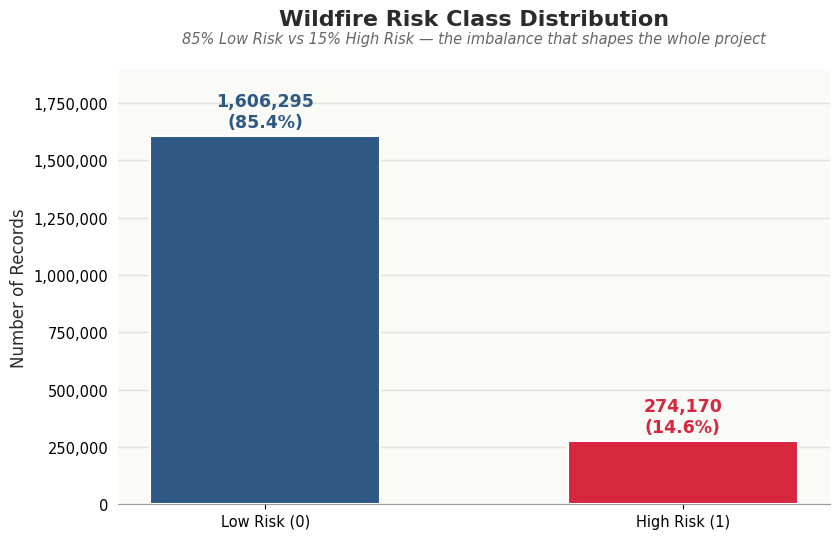

Chart 1 saved.


In [7]:
def plot_risk_class_distribution():
    """Draw a bar chart comparing Low Risk vs High Risk fire counts."""
    # ============================================================
    # CELL 6 — EDA: CHART 1 — Risk Class Distribution
    # ============================================================

    WILDFIRE_PALETTE = {                                                   # shared colour identity used across every EDA chart
        'low_risk'  : '#2E5984',                                           # slate blue = Low Risk / calm
        'high_risk' : '#D7263D',                                           # ember red = High Risk / fire intensity
        'amber'     : '#F4A623',                                           # warm amber accent
        'ink'       : '#2B2B2B',                                           # charcoal for titles/text
        'grid'      : '#E4E1D8',                                           # soft warm grey for gridlines
        'panel'     : '#FAFAF7',                                           # off-white background tint
    }

    fig, ax = plt.subplots(figsize=(8.5,5.5))                              # create the figure and axis, slightly taller canvas
    fig.patch.set_facecolor('white')                                       # white figure background
    ax.set_facecolor(WILDFIRE_PALETTE['panel'])                            # soft off-white plot background for visual warmth

    vals   = [counts.get(0,0), counts.get(1,0)]                            # bar heights: [Low Risk count, High Risk count]
    colors = [WILDFIRE_PALETTE['low_risk'], WILDFIRE_PALETTE['high_risk']] # consistent palette colours

    bars = ax.bar(['Low Risk (0)','High Risk (1)'], vals,                  # draw the two bars
                  color=colors, edgecolor='white', linewidth=1.5, width=0.55,
                  zorder=3)                                                 # bars drawn above the gridlines

    ax.set_title('Wildfire Risk Class Distribution', fontsize=16,           # main title, bold and large for presentation
                 fontweight='bold', color=WILDFIRE_PALETTE['ink'], pad=32)
    ax.text(0.5, 1.06, '85% Low Risk vs 15% High Risk — the imbalance that shapes the whole project',  # subtitle line
            transform=ax.transAxes, ha='center', fontsize=10.5,
            color='#666666', style='italic')
    ax.set_ylabel('Number of Records', fontsize=12, color=WILDFIRE_PALETTE['ink'])  # y-axis label

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))  # comma-formatted y-axis ticks
    ax.grid(axis='y', color=WILDFIRE_PALETTE['grid'], linewidth=1, zorder=0)        # soft horizontal gridlines behind the bars
    ax.spines[['top','right','left']].set_visible(False)                           # remove all but the bottom spine for a clean look
    ax.spines['bottom'].set_color('#999999')                                       # subtle grey bottom axis line
    ax.tick_params(left=False, labelsize=10.5)                                     # remove tick marks on the y-axis, keep labels

    offset = max(vals) * 0.025                                              # small vertical gap so labels don't touch the bar top
    for bar, v, c in zip(bars, vals, colors):                               # loop through each bar, its value, and its colour
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+offset,     # position the label centred above the bar
                f'{v:,}\n({v/total*100:.1f}%)', ha='center', fontsize=12.5,
                fontweight='bold', color=c)                                 # label coloured to match its bar

    ax.set_ylim(0, max(vals) * 1.18)                                        # extra headroom so the top labels aren't clipped

    plt.tight_layout()                                                      # auto-adjust spacing to avoid overlap
    plt.savefig('outputs/charts/chart1_risk_distribution.png', dpi=200, facecolor='white', bbox_inches='tight')  # high-res save
    plt.show()                                                               # render the chart in the notebook
    print("Chart 1 saved.")                                                  # confirmation message
    globals().update(locals())  # keep results available to later cells

plot_risk_class_distribution()


## 7. EDA — Chart 2: Fires Per Year

Shows how wildfire frequency in the dataset changes across the 1992–2015 study period.

**Key Points**
- Line chart with a shaded area underneath, one point per year.
- Useful for spotting trend or volatility over time (e.g. unusually high-fire years) before any modelling happens.
- Helps justify why `FIRE_YEAR` is included as a model feature — frequency clearly varies by year.
- Saved to `outputs/charts/chart2_fires_by_year.png`.


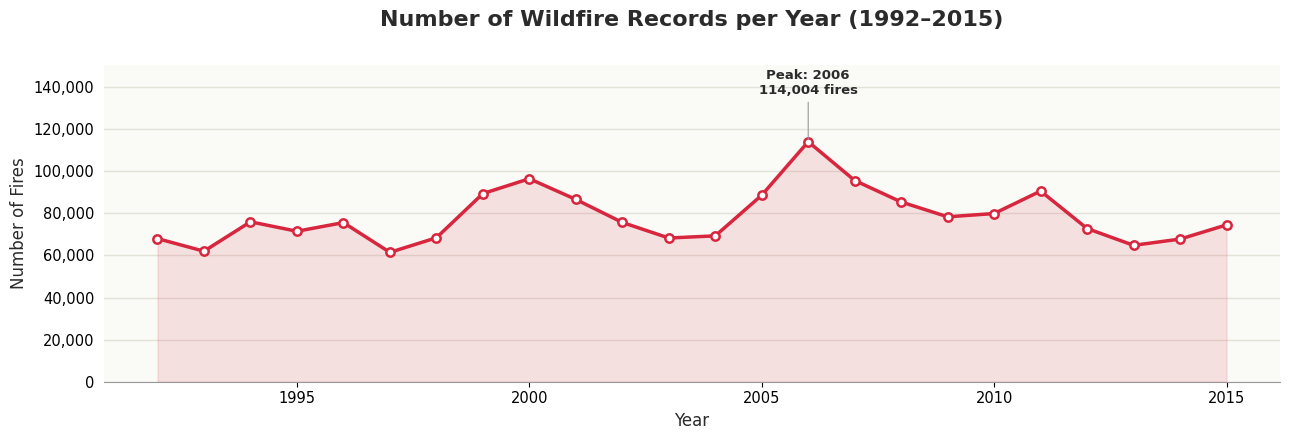

Chart 2 saved.


In [8]:
def plot_fires_per_year():
    """Draw a line chart showing how many fires happened each year."""
    # ============================================================
    # CELL 7 — EDA: CHART 2 — Fires Per Year
    # ============================================================

    yc = df.groupby('FIRE_YEAR').size()                                    # count number of fires per year

    fig, ax = plt.subplots(figsize=(13,4.5))                               # wide canvas suited to a year-by-year timeline
    fig.patch.set_facecolor('white')                                        # white figure background
    ax.set_facecolor(WILDFIRE_PALETTE['panel'])                            # soft off-white plot background

    ax.plot(yc.index, yc.values, marker='o', color=WILDFIRE_PALETTE['high_risk'],  # ember-red line with circle markers per year
            linewidth=2.5, markersize=6, markerfacecolor='white',
            markeredgecolor=WILDFIRE_PALETTE['high_risk'], markeredgewidth=1.8,
            zorder=3)

    ax.fill_between(yc.index, yc.values, alpha=0.12,                       # light shaded area under the line for visual emphasis
                    color=WILDFIRE_PALETTE['high_risk'], zorder=2)

    peak_year, peak_val = yc.idxmax(), yc.max()                            # find the single highest-fire year to call out

    # --- give the chart extra headroom so the annotation has room to breathe ---
    ax.set_ylim(0, peak_val * 1.32)                                        # push the y-axis ceiling well above the peak

    ax.annotate(f'Peak: {peak_year}\n{peak_val:,} fires',                  # annotate the peak year directly on the chart
                xy=(peak_year, peak_val), xytext=(peak_year, peak_val*1.20),  # moved further from the point, but now safely below the title
                ha='center', fontsize=9.5, fontweight='bold',
                color=WILDFIRE_PALETTE['ink'],
                arrowprops=dict(arrowstyle='-', color='#999999', lw=0.8))

    ax.set_title('Number of Wildfire Records per Year (1992–2015)', fontsize=16,   # main title
                 fontweight='bold', color=WILDFIRE_PALETTE['ink'], pad=28)          # increased pad so title sits clear of the annotation

    ax.set_xlabel('Year', fontsize=12, color=WILDFIRE_PALETTE['ink'])              # x-axis label
    ax.set_ylabel('Number of Fires', fontsize=12, color=WILDFIRE_PALETTE['ink'])   # y-axis label

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}')) # comma-formatted y-axis ticks
    ax.grid(axis='y', color=WILDFIRE_PALETTE['grid'], linewidth=1, zorder=0)       # soft horizontal gridlines
    ax.spines[['top','right','left']].set_visible(False)                          # clean spines, bottom only
    ax.spines['bottom'].set_color('#999999')
    ax.tick_params(left=False, labelsize=10.5)

    plt.tight_layout()                                                      # auto-adjust spacing
    plt.savefig('outputs/charts/chart2_fires_by_year.png', dpi=200, facecolor='white', bbox_inches='tight')  # save chart
    plt.show()                                                               # render chart in the notebook
    print("Chart 2 saved.")                                                  # confirmation message
    globals().update(locals())  # keep results available to later cells

plot_fires_per_year()

## 8. EDA — Chart 3: Top 10 Causes

Identifies which causes are most frequently responsible for wildfires in the dataset.

**Key Points**
- Horizontal bar chart of the 10 most common values in `STAT_CAUSE_DESCR`, sorted so the most frequent cause appears at the top.
- Purple gradient shading makes the ranking visually obvious at a glance.
- Supports the case for including `CAUSE_ENC` as a model feature — cause is clearly not evenly distributed.
- Saved to `outputs/charts/chart3_top_causes.png`.


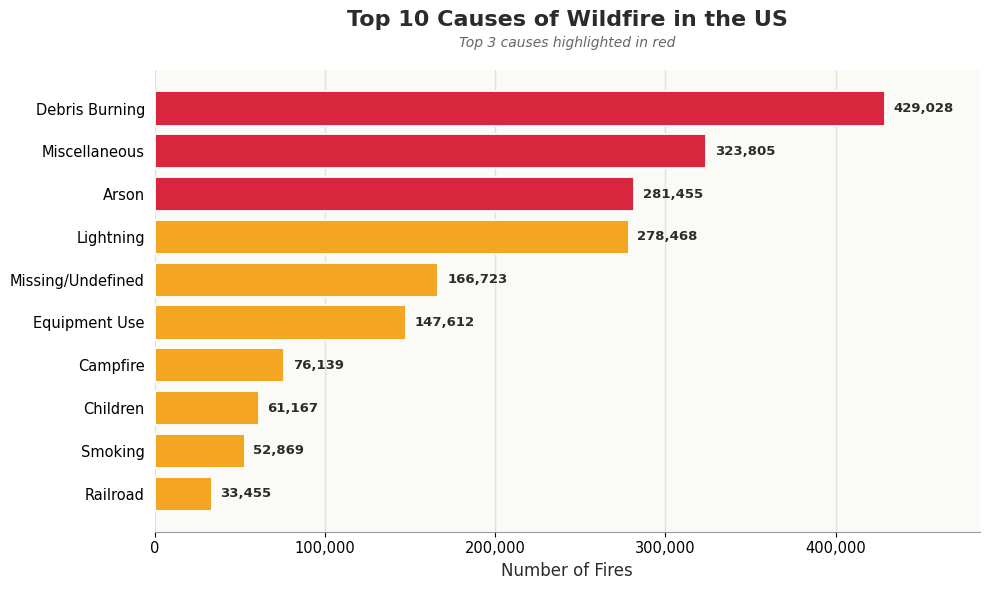

Chart 3 saved.


In [9]:
def plot_top_causes():
    """Draw a bar chart of the 10 most common fire causes."""
    # ============================================================
    # CELL 8 — EDA: CHART 3 — Top 10 Causes
    # ============================================================

    cause_counts = df['STAT_CAUSE_DESCR'].value_counts().head(10).sort_values()  # top 10 fire causes, sorted ascending so the longest bar is at the top

    fig, ax = plt.subplots(figsize=(10,6))                                  # canvas for the horizontal bar chart
    fig.patch.set_facecolor('white')                                         # white figure background
    ax.set_facecolor(WILDFIRE_PALETTE['panel'])                             # soft off-white plot background

    n_bars   = len(cause_counts)                                             # number of causes being plotted (10)
    shades   = [WILDFIRE_PALETTE['amber'] if i < n_bars-3 else WILDFIRE_PALETTE['high_risk']  # top 3 causes highlighted in ember red
                for i in range(n_bars)]                                      # rest shaded in amber

    bars = ax.barh(cause_counts.index, cause_counts.values,                  # draw horizontal bars
                   color=shades, edgecolor='white', linewidth=1.3, zorder=3)

    ax.set_title('Top 10 Causes of Wildfire in the US', fontsize=16,         # main title
                 fontweight='bold', color=WILDFIRE_PALETTE['ink'], pad=32)
    ax.text(0.5, 1.05, 'Top 3 causes highlighted in red', transform=ax.transAxes,  # subtitle explaining the highlight
            ha='center', fontsize=10, color='#666666', style='italic')
    ax.set_xlabel('Number of Fires', fontsize=12, color=WILDFIRE_PALETTE['ink'])    # x-axis label

    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))  # comma-formatted x-axis ticks
    ax.grid(axis='x', color=WILDFIRE_PALETTE['grid'], linewidth=1, zorder=0)        # soft vertical gridlines
    ax.spines[['top','right','left']].set_visible(False)                           # clean spines, bottom only
    ax.spines['bottom'].set_color('#999999')
    ax.tick_params(left=False, labelsize=10.5)

    max_val = cause_counts.values.max()                                      # used to position value labels consistently
    for bar, v in zip(bars, cause_counts.values):                            # loop through each bar and its value
        ax.text(bar.get_width()+max_val*0.012, bar.get_y()+bar.get_height()/2,  # position the label just past the bar end
                f'{v:,}', va='center', fontsize=9.5, fontweight='bold',
                color=WILDFIRE_PALETTE['ink'])

    ax.set_xlim(0, max_val*1.13)                                              # extra headroom so labels aren't clipped

    plt.tight_layout()                                                        # auto-adjust spacing
    plt.savefig('outputs/charts/chart3_top_causes.png', dpi=200, facecolor='white', bbox_inches='tight')  # save chart
    plt.show()                                                                 # render chart in the notebook
    print("Chart 3 saved.")                                                   # confirmation message
    globals().update(locals())  # keep results available to later cells

plot_top_causes()


## 9. EDA — Chart 4: Fires by Season

Shows how wildfire frequency varies across the four seasons.

**Key Points**
- Bar chart in a fixed Spring → Summer → Autumn → Winter order (not alphabetical), so the seasonal cycle reads naturally left to right.
- Each bar is colour-coded to its season (green/orange/brown/blue) and labelled with its exact count.
- Justifies including `SEASON` as a model feature — wildfire activity is clearly seasonal, not uniform.
- Saved to `outputs/charts/chart4_season.png`.


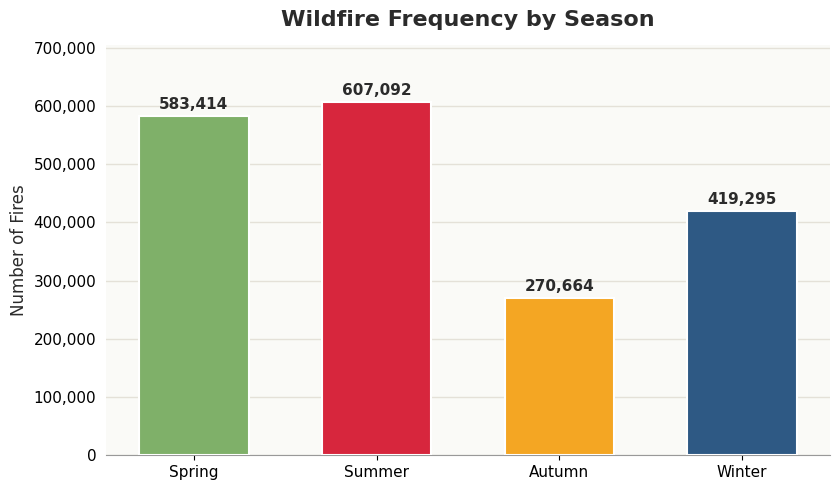

Chart 4 saved.


In [10]:
def plot_fires_by_season():
    """Draw a bar chart showing fire counts in each season."""
    # ============================================================
    # CELL 9 — EDA: CHART 4 — Fires by Season
    # ============================================================

    sc = df['SEASON_NAME'].value_counts().reindex(                           # count fires per season
        ['Spring','Summer','Autumn','Winter'], fill_value=0)                # force a fixed, logical season order

    fig, ax = plt.subplots(figsize=(8.5,5))                                  # canvas for the seasonal bar chart
    fig.patch.set_facecolor('white')                                          # white figure background
    ax.set_facecolor(WILDFIRE_PALETTE['panel'])                              # soft off-white plot background

    season_colors = ['#7FB069', WILDFIRE_PALETTE['high_risk'],               # green=Spring, ember red=Summer (peak fire season)
                      WILDFIRE_PALETTE['amber'], WILDFIRE_PALETTE['low_risk']]  # amber=Autumn, slate blue=Winter

    bars = ax.bar(sc.index, sc.values,                                        # draw one bar per season
                  color=season_colors, edgecolor='white', linewidth=1.5,
                  width=0.6, zorder=3)

    ax.set_title('Wildfire Frequency by Season', fontsize=16,                 # main title
                 fontweight='bold', color=WILDFIRE_PALETTE['ink'], pad=14)
    ax.set_ylabel('Number of Fires', fontsize=12, color=WILDFIRE_PALETTE['ink'])  # y-axis label

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))  # comma-formatted y-axis ticks
    ax.grid(axis='y', color=WILDFIRE_PALETTE['grid'], linewidth=1, zorder=0)        # soft horizontal gridlines
    ax.spines[['top','right','left']].set_visible(False)                           # clean spines, bottom only
    ax.spines['bottom'].set_color('#999999')
    ax.tick_params(left=False, labelsize=11)

    max_val = sc.values.max()                                                  # used for consistent label offset and headroom
    for bar, v in zip(bars, sc.values):                                        # loop through each bar and its value
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max_val*0.02,  # position label just above the bar
                f'{v:,}', ha='center', fontsize=11, fontweight='bold',
                color=WILDFIRE_PALETTE['ink'])

    ax.set_ylim(0, max_val*1.16)                                               # extra headroom so labels aren't clipped

    plt.tight_layout()                                                         # auto-adjust spacing
    plt.savefig('outputs/charts/chart4_season.png', dpi=200, facecolor='white', bbox_inches='tight')  # save chart
    plt.show()                                                                  # render chart in the notebook
    print("Chart 4 saved.")                                                    # confirmation message
    globals().update(locals())  # keep results available to later cells

plot_fires_by_season()


## 10. EDA — Chart 5: Risk by Region

Breaks down High Risk vs Low Risk fire counts across the 5 US regions.

**Key Points**
- Grouped bar chart, one blue (Low Risk) and one red (High Risk) bar per region, sorted by High Risk count so the riskiest region appears first.
- Reveals whether risk is geographically concentrated rather than spread evenly across the country.
- Supports the inclusion of `REGION_ENC` as a feature, and sets up the geographic story continued in the Folium heatmap next.
- Saved to `outputs/charts/chart5_region_risk.png`.


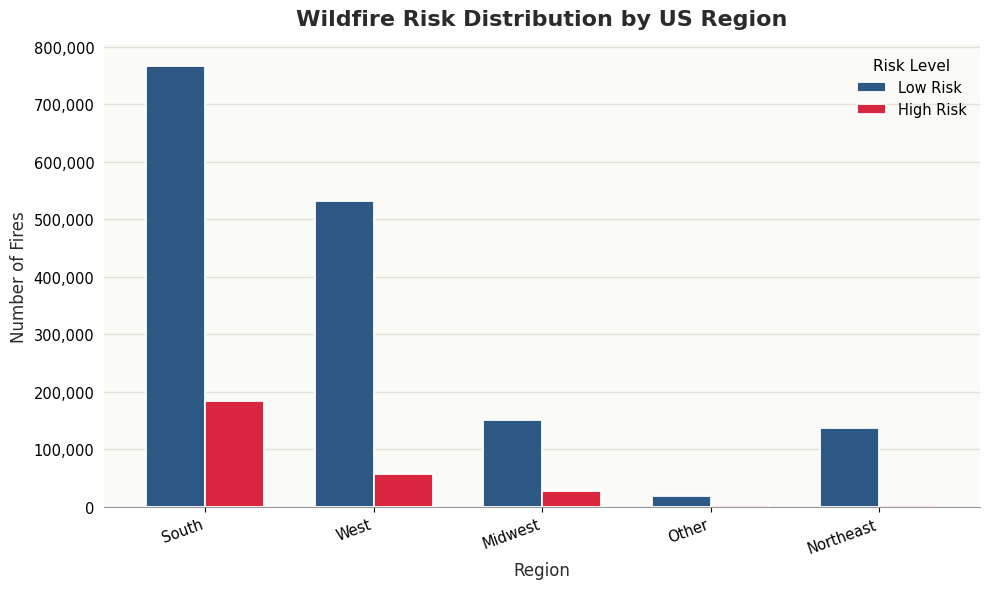

Chart 5 saved.


In [11]:
def plot_risk_by_region():
    """Draw a bar chart comparing Low vs High Risk fires across US regions."""
    # ============================================================
    # CELL 10 — EDA: CHART 5 — Risk by Region
    # ============================================================

    rr = df.groupby(['REGION','RISK_BINARY']).size().unstack(fill_value=0)   # count rows per region/risk pair, pivot risk into columns
    rr.columns = ['Low Risk','High Risk']                                     # rename the pivoted columns for readability

    rr = rr.sort_values('High Risk', ascending=False)                        # sort so the highest-risk region appears first

    fig, ax = plt.subplots(figsize=(10,6))                                    # canvas for the grouped bar chart
    fig.patch.set_facecolor('white')                                           # white figure background
    ax.set_facecolor(WILDFIRE_PALETTE['panel'])                               # soft off-white plot background

    bars = rr.plot(kind='bar', ax=ax,                                         # draw grouped bars
            color=[WILDFIRE_PALETTE['low_risk'], WILDFIRE_PALETTE['high_risk']],  # slate blue=Low Risk, ember red=High Risk
            edgecolor='white', linewidth=1.3, width=0.7, zorder=3)

    ax.set_title('Wildfire Risk Distribution by US Region', fontsize=16,      # main title
                 fontweight='bold', color=WILDFIRE_PALETTE['ink'], pad=14)
    ax.set_xlabel('Region', fontsize=12, color=WILDFIRE_PALETTE['ink'])               # x-axis label
    ax.set_ylabel('Number of Fires', fontsize=12, color=WILDFIRE_PALETTE['ink'])      # y-axis label

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))    # comma-formatted y-axis ticks
    ax.grid(axis='y', color=WILDFIRE_PALETTE['grid'], linewidth=1, zorder=0)          # soft horizontal gridlines
    ax.spines[['top','right','left']].set_visible(False)                             # clean spines, bottom only
    ax.spines['bottom'].set_color('#999999')
    ax.tick_params(left=False, labelsize=10.5)

    ax.legend(title='Risk Level', fontsize=10.5, title_fontsize=11,           # legend identifying the two bar colours
              frameon=False, loc='upper right')
    plt.xticks(rotation=20, ha='right', fontsize=10.5)                        # rotate region labels so they don't overlap

    plt.tight_layout()                                                         # auto-adjust spacing
    plt.savefig('outputs/charts/chart5_region_risk.png', dpi=200, facecolor='white', bbox_inches='tight')  # save chart
    plt.show()                                                                  # render chart in the notebook
    print("Chart 5 saved.")                                                    # confirmation message
    globals().update(locals())  # keep results available to later cells

plot_risk_by_region()


## 10b. EDA — Interactive Folium Heatmap (High-Risk Fires)

Plots the geographic density of High Risk fires across the continental US as an interactive heatmap.

**Key Points**
- Filters to High Risk fires only (`RISK_BINARY == 1`) and drops any rows missing coordinates.
- Samples down to 50,000 points (`random_state=42` for reproducibility) so the HTML map stays responsive in a browser.
- Map is centred on the continental US (`[39.5, -98.35]`) using a clean, light `CartoDB positron` basemap style.
- Saved as a standalone interactive file (`outputs/charts/heatmap_high_risk.html`) — this can be opened independently of the notebook, e.g. embedded in a presentation or shared separately.
- Complements Chart 5: where Chart 5 shows risk *by region*, this shows risk *by exact location*.


In [12]:
def plot_heatmap():
    """Draw an interactive map showing where High Risk fires are concentrated."""
    # ============================================================
    # CELL 10b — EDA: FOLIUM INTERACTIVE HEATMAP (High-Risk Fires)
    # ============================================================
    # Geographic density of HIGH-RISK fires across the US.
    # Sampled to 50k points so the map stays responsive in the browser.
    from folium.plugins import HeatMap, Fullscreen                            # HeatMap layer + a fullscreen view toggle
    import branca.colormap as bcm                                              # used to build the gradient legend shown on the map

    high_risk = df[df['RISK_BINARY'] == 1][['LATITUDE','LONGITUDE']].dropna()           # only high-risk fires, drop any missing coords
    sample    = high_risk.sample(n=min(50000, len(high_risk)), random_state=42)         # cap points so the HTML map renders fast

    m = folium.Map(location=[39.5, -98.35], zoom_start=4.3, tiles='CartoDB positron',   # base map centred on continental US
                    control_scale=True)                                                 # show a distance scale bar in the corner

    fire_gradient = {0.2: '#2E5984', 0.4: '#F4A623', 0.7: '#F46B22', 1.0: '#D7263D'}    # cool-to-hot gradient: blue -> amber -> red, matches the EDA palette
    HeatMap(sample.values.tolist(), radius=9, blur=7, max_zoom=6,                        # add the heat layer
            gradient=fire_gradient).add_to(m)

    legend = bcm.LinearColormap(                                                         # build a colour-bar legend matching the heat gradient
        colors=['#2E5984','#F4A623','#F46B22','#D7263D'],
        vmin=0, vmax=1, caption='High-Risk Fire Density (low \u2192 high)')
    legend.add_to(m)                                                                      # attach the legend to the map corner

    Fullscreen(position='topright', title='Expand map', title_cancel='Exit fullscreen',  # adds a fullscreen toggle button
               force_separate_button=True).add_to(m)

    title_html = '''
         <div style="position: fixed; top: 12px; left: 60px; z-index: 9999;
                     background-color: white; padding: 8px 16px; border-radius: 6px;
                     box-shadow: 0 1px 6px rgba(0,0,0,0.25);
                     font-size: 16px; font-weight: bold; color: #2B2B2B;">
             Geographic Density of High-Risk Wildfires (US, 1992&ndash;2015)
         </div>
         '''                                                                              # floating title box overlaid on the map
    m.get_root().html.add_child(folium.Element(title_html))                              # inject the title box into the map HTML

    m.save('outputs/charts/heatmap_high_risk.html')                                       # save standalone interactive map
    print(f"Folium heatmap saved -> outputs/charts/heatmap_high_risk.html ({len(sample):,} points)")
    m                                                                                      # display inline in Colab
    globals().update(locals())  # keep results available to later cells

plot_heatmap()


Folium heatmap saved -> outputs/charts/heatmap_high_risk.html (50,000 points)


## 11. Prepare Features & Train/Test Split

Selects the final feature set, splits the data into training and test sets, and scales the features — the last step before any model training begins.

**Key Points**
- **9 features used**: `FIRE_YEAR`, `MONTH`, `SEASON`, `CAUSE_ENC`, `LATITUDE`, `LONGITUDE`, `REGION_ENC`, `OWNER_ENC`, `STATE_ENC`.
- **`FIRE_SIZE_LOG` is deliberately excluded** — it directly encodes the same information as the target (`FIRE_SIZE_CLASS`), so including it would cause data leakage and produce fake, inflated scores.
- Any non-numeric or missing feature values are coerced to numeric and filled with the column median.
- **70% train / 30% test split**, stratified by `y` so both sets keep the same ~85/15 risk ratio.
- `StandardScaler` is **fit on training data only**, then applied to both train and test — this is the correct way to scale without leaking test-set information into training.


In [13]:
def prepare_train_test_split():
    """Pick the model features and split data into training and test sets."""
    # ============================================================
    # CELL 11 — PREPARE FEATURES & TRAIN/TEST SPLIT
    # ============================================================

    # FIRE_SIZE_LOG excluded — it directly encodes FIRE_SIZE which is the
    # same information as FIRE_SIZE_CLASS (target). Including it causes
    # data leakage and produces fake 1.0000 scores.
    candidates   = ['FIRE_YEAR','MONTH','SEASON',                            # candidate feature columns to consider for modelling
                    'CAUSE_ENC','LATITUDE','LONGITUDE',
                    'REGION_ENC','OWNER_ENC','STATE_ENC']
    feature_cols = [c for c in candidates if c in df.columns]                # keep only candidates that actually exist in df
    print(f"Features selected ({len(feature_cols)}): {feature_cols}")        # confirm the final feature list

    X = df[feature_cols].copy()                                              # X = model inputs (independent variables)
    y = df['RISK_BINARY'].copy()                                             # y = model target (what we want to predict)

    for col in X.columns:                                                     # loop through every feature column
        X[col] = pd.to_numeric(X[col], errors='coerce')                       # force numeric dtype, turn bad values into NaN
    X.fillna(X.median(), inplace=True)                                        # fill any remaining NaNs with the column median

    X_train, X_test, y_train, y_test = train_test_split(                      # split into 70% train / 30% test
        X, y, test_size=0.3, random_state=42, stratify=y)                    # stratify=y keeps the 85/15 risk ratio in both sets

    scaler     = StandardScaler()                                             # scaler to standardise features to mean=0, std=1
    X_train_sc = scaler.fit_transform(X_train)                                # fit the scaler on train data only, then transform it
    X_test_sc  = scaler.transform(X_test)                                     # transform test data using the SAME scaler (no leakage)

    print(f"\n   Total : {len(df):,} rows")                                   # total rows in the cleaned dataset
    print(f"   Train : {X_train_sc.shape[0]:,} rows (70%)")                  # size of the training set
    print(f"   Test  : {X_test_sc.shape[0]:,} rows (30%)")                   # size of the test set
    globals().update(locals())  # keep results available to later cells

prepare_train_test_split()


Features selected (9): ['FIRE_YEAR', 'MONTH', 'SEASON', 'CAUSE_ENC', 'LATITUDE', 'LONGITUDE', 'REGION_ENC', 'OWNER_ENC', 'STATE_ENC']

   Total : 1,880,465 rows
   Train : 1,316,325 rows (70%)
   Test  : 564,140 rows (30%)


## 12. Class Balancing (Fix 85/15 Imbalance for Baseline Models)

Creates a class-balanced version of the training data so the 4 baseline models don't simply learn to always predict "Low Risk."

**Key Points**
- Uses `RandomUnderSampler` to remove Low Risk rows until the classes are 50/50 — this only touches the **training** data, never the test set.
- Produces `X_balanced` / `y_balanced`, which feed directly into Ridge, Random Forest, default XGBoost, and MLP in the next 4 cells.
- The proposed final model (Balanced Bagging + XGBoost) is handled differently — it does its **own** internal balancing later and trains on the original, unbalanced `X_train_sc` / `y_train` instead.
- Prints the before/after class counts so the balancing effect is visible and verifiable.


In [14]:
def balance_training_classes():
    """Fix the imbalance between Low Risk and High Risk rows in the training data."""
    # ============================================================
    # CELL 12 — CLASS BALANCING (Fix 85/15 Imbalance for Baseline Models)
    # ============================================================

    print("Class Balancing — RandomUnderSampler")                            # section header
    print("   The 4 baseline models below (Ridge, RF, XGBoost, MLP) are")    # explanatory note line 1
    print("   trained on an undersampled, class-balanced version of the")    # explanatory note line 2
    print("   training data so they learn both classes equally.\n")          # explanatory note line 3

    rus = RandomUnderSampler(random_state=42)                                  # undersampler: removes majority-class rows to balance classes
    X_balanced, y_balanced = rus.fit_resample(X_train_sc, y_train)             # apply it to the scaled training data only (never the test set)

    counts_bal = pd.Series(y_balanced).value_counts()                          # count classes after balancing, for the printout below
    print(f"   Original — Low Risk : {(y_train==0).sum():,}  High Risk : {(y_train==1).sum():,}")  # class counts before balancing
    print(f"   Balanced — Low Risk : {counts_bal[0]:,}  High Risk : {counts_bal[1]:,}")              # class counts after balancing
    print(f"   Balanced shape      : {X_balanced.shape}")                                              # shape of the balanced feature matrix
    print(f"\nX_balanced / y_balanced ready — the 4 baseline models below will train on this.")        # confirms what comes next
    print("(The proposed final model, Balanced Bagging + XGBoost, handles its own")                    # clarifies the proposed model differs
    print(" internal balancing and is trained later on the original X_train_sc.)")                     # explains where it gets its data
    globals().update(locals())  # keep results available to later cells

balance_training_classes()


Class Balancing — RandomUnderSampler
   The 4 baseline models below (Ridge, RF, XGBoost, MLP) are
   trained on an undersampled, class-balanced version of the
   training data so they learn both classes equally.

   Original — Low Risk : 1,124,406  High Risk : 191,919
   Balanced — Low Risk : 191,919  High Risk : 191,919
   Balanced shape      : (383838, 9)

X_balanced / y_balanced ready — the 4 baseline models below will train on this.
(The proposed final model, Balanced Bagging + XGBoost, handles its own
 internal balancing and is trained later on the original X_train_sc.)


## 13. Model 1 — Ridge Classifier (Baseline)

Trains the simplest model in the comparison: a linear classifier with L2 regularisation, used as the baseline every other model must beat.

**Key Points**
- `alpha=1.0` controls regularisation strength — higher values penalise large coefficients more, helping prevent overfitting.
- Trained on the class-balanced data (`X_balanced`, `y_balanced`).
- Ridge has no `predict_proba`, so `decision_function` (raw scores) is used instead for the ROC-AUC calculation.
- Reports Accuracy, F1-Score, ROC-AUC, and a full classification report on the untouched test set.
- Train-set predictions are also stored (`ridge_train_pred`) for the overfitting check used later in the notebook.


In [15]:
def train_ridge_model():
    """Train a simple linear (Ridge) model as our baseline."""
    # ============================================================
    # CELL 13 — MODEL 1: RIDGE CLASSIFIER (Baseline)
    # ============================================================

    # alpha=1.0 = regularisation strength (higher = stronger penalty)
    # decision_function = raw scores used for ROC-AUC (no predict_proba in Ridge)
    ridge      = RidgeClassifier(alpha=1.0)                                   # initialise the Ridge classifier with default regularisation
    ridge.fit(X_balanced, y_balanced)                                          # train on the class-balanced training data
    ridge_pred = ridge.predict(X_test_sc)                                      # predict class labels (0/1) on the test set
    ridge_prob = ridge.decision_function(X_test_sc)                            # raw decision scores on the test set, used for ROC-AUC
    ridge_train_pred = ridge.predict(X_balanced)                               # predictions on the data it was trained on, for the overfitting check later

    print("Model 1: Ridge Classifier (Baseline)")                              # section header
    print(f"   Accuracy : {accuracy_score(y_test, ridge_pred):.4f}")          # overall accuracy on the test set
    print(f"   F1-Score : {f1_score(y_test, ridge_pred):.4f}")                # F1-score balances precision and recall
    print(f"   ROC-AUC  : {roc_auc_score(y_test, ridge_prob):.4f}")           # ROC-AUC, how well the model ranks High vs Low Risk
    print(classification_report(y_test, ridge_pred, target_names=['Low Risk','High Risk'], digits=4))  # detailed per-class precision/recall/F1
    globals().update(locals())  # keep results available to later cells

train_ridge_model()


Model 1: Ridge Classifier (Baseline)
   Accuracy : 0.5639
   F1-Score : 0.2823
   ROC-AUC  : 0.6005
              precision    recall  f1-score   support

    Low Risk     0.8884    0.5598    0.6868    481889
   High Risk     0.1857    0.5881    0.2823     82251

    accuracy                         0.5639    564140
   macro avg     0.5371    0.5740    0.4846    564140
weighted avg     0.7860    0.5639    0.6279    564140



## 14. Model 2 — Random Forest (Tree-based)

Trains an ensemble of 200 decision trees — a non-linear model that typically handles noisy, structured tabular data better than a linear baseline.

**Key Points**
- `n_estimators=200` trees, `n_jobs=-1` to use all available CPU cores for faster training.
- Trained on the same class-balanced data as Ridge, for a fair comparison.
- Uses `predict_proba[:,1]` (probability of High Risk) for ROC-AUC, since Random Forest natively supports probability outputs (unlike Ridge).
- Reports the same 3 core metrics (Accuracy, F1, ROC-AUC) plus the full classification report, in the same format as every other model for easy side-by-side comparison.


In [16]:
def train_random_forest_model():
    """Train a Random Forest model made of 200 decision trees."""
    # ============================================================
    # CELL 14 — MODEL 2: RANDOM FOREST (Tree-based)
    # ============================================================

    # n_estimators=200 = number of trees
    # n_jobs=-1 = use all CPU cores
    # predict_proba[:,1] = probability score for High Risk class
    rf      = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)  # initialise a forest of 200 decision trees
    rf.fit(X_balanced, y_balanced)                                              # train on the class-balanced training data
    rf_pred = rf.predict(X_test_sc)                                            # predict class labels (0/1) on the test set
    rf_prob = rf.predict_proba(X_test_sc)[:,1]                                 # probability of High Risk, used for ROC-AUC
    rf_train_pred = rf.predict(X_balanced)                                     # predictions on the data it was trained on, for the overfitting check later

    print("Model 2: Random Forest (Tree-based)")                               # section header
    print(f"   Accuracy : {accuracy_score(y_test, rf_pred):.4f}")             # overall accuracy on the test set
    print(f"   F1-Score : {f1_score(y_test, rf_pred):.4f}")                   # F1-score balances precision and recall
    print(f"   ROC-AUC  : {roc_auc_score(y_test, rf_prob):.4f}")              # ROC-AUC, how well the model ranks High vs Low Risk
    print(classification_report(y_test, rf_pred, target_names=['Low Risk','High Risk'], digits=4))  # detailed per-class precision/recall/F1
    globals().update(locals())  # keep results available to later cells

train_random_forest_model()


Model 2: Random Forest (Tree-based)
   Accuracy : 0.7169
   F1-Score : 0.4279
   ROC-AUC  : 0.7943
              precision    recall  f1-score   support

    Low Risk     0.9387    0.7153    0.8119    481889
   High Risk     0.3033    0.7262    0.4279     82251

    accuracy                         0.7169    564140
   macro avg     0.6210    0.7208    0.6199    564140
weighted avg     0.8461    0.7169    0.7559    564140



## 15. Model 3 — XGBoost (Boosting, Default Parameters)

Trains a gradient-boosted tree model using a reasonable set of hand-picked default parameters, before any Optuna tuning happens.

**Key Points**
- `n_estimators=300` boosting rounds, `max_depth=8`, `learning_rate=0.05` — moderate complexity settings, not yet optimised.
- `subsample=0.8` and `colsample_bytree=0.8` mean each tree only sees 80% of rows and 80% of features, which helps reduce overfitting.
- This is the version of XGBoost used purely as a **baseline comparison point** — the tuned version (Cell 19) is what actually feeds into the proposed final model.
- Trained on the same balanced data as Ridge and Random Forest for a fair, like-for-like comparison.


In [17]:
def train_xgboost_default_model():
    """Train an XGBoost model using reasonable default settings."""
    # ============================================================
    # CELL 15 — MODEL 3: XGBOOST (Boosting, Default Parameters)
    # ============================================================

    # n_estimators=300 = number of boosting rounds
    # max_depth=8 = maximum tree depth
    # learning_rate=0.05 = step size per round
    # subsample=0.8 = 80% of rows used per tree
    # colsample_bytree=0.8 = 80% of columns used per tree
    # verbosity=0 = silent training
    xgb_def      = XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.05,    # default-parameter XGBoost configuration
                                  subsample=0.8, colsample_bytree=0.8,
                                  eval_metric='logloss', random_state=42, verbosity=0)
    xgb_def.fit(X_balanced, y_balanced)                                          # train on the class-balanced training data
    xgb_def_pred = xgb_def.predict(X_test_sc)                                    # predict class labels (0/1) on the test set
    xgb_def_prob = xgb_def.predict_proba(X_test_sc)[:,1]                        # probability of High Risk, used for ROC-AUC

    print("Model 3: XGBoost (Boosting, Default)")                                # section header
    print(f"   Accuracy : {accuracy_score(y_test, xgb_def_pred):.4f}")          # overall accuracy on the test set
    print(f"   F1-Score : {f1_score(y_test, xgb_def_pred):.4f}")                # F1-score balances precision and recall
    print(f"   ROC-AUC  : {roc_auc_score(y_test, xgb_def_prob):.4f}")           # ROC-AUC, how well the model ranks High vs Low Risk
    print(classification_report(y_test, xgb_def_pred, target_names=['Low Risk','High Risk'], digits=4))  # detailed per-class precision/recall/F1
    globals().update(locals())  # keep results available to later cells

train_xgboost_default_model()


Model 3: XGBoost (Boosting, Default)
   Accuracy : 0.7109
   F1-Score : 0.4276
   ROC-AUC  : 0.7972
              precision    recall  f1-score   support

    Low Risk     0.9410    0.7059    0.8067    481889
   High Risk     0.3006    0.7405    0.4276     82251

    accuracy                         0.7109    564140
   macro avg     0.6208    0.7232    0.6171    564140
weighted avg     0.8476    0.7109    0.7514    564140



## 16. Model 4 — MLP (Neural Network)

Trains a 2-hidden-layer neural network, representing the deep learning comparison point against the 3 tree/linear-based models.

**Key Points**
- Architecture: 128 neurons in the first hidden layer, 64 in the second — first layer learns broad patterns, second layer refines them toward the final risk prediction.
- `early_stopping=True` automatically halts training once validation performance stops improving, which helps prevent overfitting without manually tuning the number of epochs.
- `max_iter=300` caps the maximum number of training passes if early stopping doesn't trigger first.
- Completes the set of all 4 baseline models — Ridge, Random Forest, XGBoost, and MLP — ready for head-to-head comparison in the next cell.


In [18]:
def train_mlp_model():
    """Train a small neural network (MLP) model."""
    # ============================================================
    # CELL 16 — MODEL 4: MLP (Neural Network)
    # ============================================================

    # hidden_layer_sizes=(128,64) -> 2 layers
    #   first layer  128 neurons -> learns broad patterns from features
    #   second layer  64 neurons -> refines and narrows down to risk prediction
    # max_iter=300 -> maximum 300 passes through training data
    # early_stopping=True -> stops automatically when model stops improving
    #   prevents overfitting — no need to manually pick the right epoch
    mlp      = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=300,        # 2-hidden-layer neural network: 128 then 64 neurons
                             random_state=42, early_stopping=True)
    mlp.fit(X_balanced, y_balanced)                                             # train on the class-balanced training data
    mlp_pred = mlp.predict(X_test_sc)                                          # predict class labels (0/1) on the test set
    mlp_prob = mlp.predict_proba(X_test_sc)[:,1]                               # probability of High Risk, used for ROC-AUC
    mlp_train_pred = mlp.predict(X_balanced)                                   # predictions on the data it was trained on, for the overfitting check later

    print("Model 4: MLP (Neural Network)")                                     # section header
    print(f"   Accuracy : {accuracy_score(y_test, mlp_pred):.4f}")            # overall accuracy on the test set
    print(f"   F1-Score : {f1_score(y_test, mlp_pred):.4f}")                  # F1-score balances precision and recall
    print(f"   ROC-AUC  : {roc_auc_score(y_test, mlp_prob):.4f}")             # ROC-AUC, how well the model ranks High vs Low Risk
    print(classification_report(y_test, mlp_pred, target_names=['Low Risk','High Risk'], digits=4))  # detailed per-class precision/recall/F1

    print("All 4 baseline models trained.")                                    # confirms all baselines are done
    globals().update(locals())  # keep results available to later cells

train_mlp_model()


Model 4: MLP (Neural Network)
   Accuracy : 0.6854
   F1-Score : 0.4036
   ROC-AUC  : 0.7718
              precision    recall  f1-score   support

    Low Risk     0.9363    0.6778    0.7864    481889
   High Risk     0.2789    0.7299    0.4036     82251

    accuracy                         0.6854    564140
   macro avg     0.6076    0.7039    0.5950    564140
weighted avg     0.8405    0.6854    0.7306    564140

All 4 baseline models trained.


## 17. Baseline Comparison (4 Models, Before Optuna)

Brings together the results of all 4 baseline models into a single comparison table — the first checkpoint of the whole modelling process.

**Key Points**
- Compares Ridge, Random Forest, XGBoost (default), and MLP side by side on Accuracy, F1-Score, and ROC-AUC.
- Automatically identifies the best-performing baseline by ROC-AUC — this determines which algorithm family is worth fine-tuning further.
- This directly answers part of **OBJ-1** ("compare ensemble models and neural network... by ROC-AUC and F1-score") at the baseline stage, before any tuning.
- Sets up the next 3 cells: Optuna tuning is applied specifically to XGBoost, since it's the strongest baseline family, and its tuned parameters are reused inside the proposed final model.


In [19]:
def compare_baseline_models():
    """Put the 4 baseline models side by side and see which one is best."""
    # ============================================================
    # CELL 17 — BASELINE COMPARISON (4 Models, Before Optuna)
    # ============================================================
    summary_baseline = pd.DataFrame({                                          # build a comparison table, one row per model
        'Model'   : ['Ridge (Baseline)','Random Forest (Tree-based)',
                     'XGBoost (Boosting)','MLP (Neural Network)'],
        'Accuracy': [accuracy_score(y_test, ridge_pred), accuracy_score(y_test, rf_pred),    # accuracy for each model
                     accuracy_score(y_test, xgb_def_pred), accuracy_score(y_test, mlp_pred)],
        'F1-Score': [f1_score(y_test, ridge_pred), f1_score(y_test, rf_pred),                 # F1-score for each model
                     f1_score(y_test, xgb_def_pred), f1_score(y_test, mlp_pred)],
        'ROC-AUC' : [roc_auc_score(y_test, ridge_prob), roc_auc_score(y_test, rf_prob),       # ROC-AUC for each model
                     roc_auc_score(y_test, xgb_def_prob), roc_auc_score(y_test, mlp_prob)],
    }).set_index('Model').round(4)                                              # use model name as the row index, round for readability

    print("BASELINE MODEL COMPARISON — Before Optuna Tuning")                  # section header
    print("="*55)                                                               # visual divider
    print(summary_baseline.to_string())                                        # print the full comparison table
    print("="*55)                                                               # visual divider

    best_baseline     = summary_baseline['ROC-AUC'].idxmax()                   # name of the baseline with the highest ROC-AUC
    best_baseline_auc = summary_baseline['ROC-AUC'].max()                      # that highest ROC-AUC value
    print(f"\nBest baseline model : {best_baseline}")                          # report the best baseline
    print(f"   Best ROC-AUC      : {best_baseline_auc:.4f}")                  # report its ROC-AUC score

    print("\nNext: XGBoost — the strongest baseline family — is fine-tuned with")  # transition message
    print("Optuna, and its tuned parameters are then reused inside the proposed")  # transition message
    print("final model (Balanced Bagging + XGBoost).")                              # transition message
    globals().update(locals())  # keep results available to later cells

compare_baseline_models()


BASELINE MODEL COMPARISON — Before Optuna Tuning
                            Accuracy  F1-Score  ROC-AUC
Model                                                  
Ridge (Baseline)              0.5639    0.2823   0.6005
Random Forest (Tree-based)    0.7169    0.4279   0.7943
XGBoost (Boosting)            0.7109    0.4276   0.7972
MLP (Neural Network)          0.6854    0.4036   0.7718

Best baseline model : XGBoost (Boosting)
   Best ROC-AUC      : 0.7972

Next: XGBoost — the strongest baseline family — is fine-tuned with
Optuna, and its tuned parameters are then reused inside the proposed
final model (Balanced Bagging + XGBoost).


## 18. Optuna Fine Tuning (XGBoost — 30 Trials)

Uses Optuna to automatically search for the best XGBoost hyperparameters, rather than tuning them by hand or using a slower Grid Search.

**Key Points**
- Tunes 9 hyperparameters at once: `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `min_child_weight`, `gamma`, `reg_alpha`, `reg_lambda`.
- Each of the 30 trials is evaluated with **3-fold cross-validation on the balanced data** (`X_balanced`), not the full training set — this avoids an artificially inflated ROC-AUC of 1.0000.
- `direction='maximize'` tells Optuna to search for the hyperparameter combination that gives the **highest mean ROC-AUC** across folds.
- The winning hyperparameters (`study.best_params`) are reused in two places later: the standalone tuned-XGBoost evaluation (Cell 19) and as the base estimator inside the proposed final model (Cell 20).


In [20]:
def tune_xgboost_with_optuna():
    """Search for the best XGBoost settings automatically using Optuna."""
    # ============================================================
    # CELL 18 — OPTUNA FINE TUNING (XGBoost — 30 Trials)
    # ============================================================

    def objective(trial):                                                       # function Optuna calls once per trial
        params = {
            'n_estimators'    : trial.suggest_int('n_estimators', 100, 600),           # number of boosting rounds — more trees can mean better accuracy
            'max_depth'       : trial.suggest_int('max_depth', 3, 12),                 # how deep each tree grows — deeper = more complex patterns
            'learning_rate'   : trial.suggest_float('learning_rate', 0.005, 0.3, log=True),  # step size per round — log scale tests small values carefully
            'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),            # fraction of rows used per tree — prevents overfitting
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),     # fraction of features used per tree — adds diversity between trees
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),          # minimum data points per leaf — higher = simpler trees
            'gamma'           : trial.suggest_float('gamma', 0, 5),                    # minimum loss reduction to split — higher = more conservative
            'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),    # L1 regularisation — penalises large weights
            'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),   # L2 regularisation — smoother weight updates

            'eval_metric':'logloss', 'verbosity':0, 'random_state':42,                 # fixed settings, not tuned by Optuna
        }

        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)               # 3-fold cross-validation, preserving class ratio in each fold
        return cross_val_score(                                                         # use X_balanced, not X_train_sc, to avoid an inflated ROC-AUC = 1.0
            XGBClassifier(**params), X_balanced, y_balanced,
            cv=skf, scoring='roc_auc', n_jobs=-1).mean()                               # average ROC-AUC across the 3 folds, this is the score Optuna maximises

    study = optuna.create_study(direction='maximize')                                  # create the study; 'maximize' means higher ROC-AUC is better

    study.optimize(objective, n_trials=30, show_progress_bar=True)                     # run 30 trials, each testing a different set of hyperparameters

    print(f"\nOptuna complete!")                                                        # section header
    print(f"   Best ROC-AUC : {study.best_value:.4f}")                                # best cross-validated ROC-AUC found across all trials
    print(f"\n   Best parameters found:")                                              # section header
    for k, v in study.best_params.items():                                              # loop through every tuned hyperparameter
        print(f"     {k:22s}: {v}")                                                     # print its winning value
    globals().update(locals())  # keep results available to later cells

tune_xgboost_with_optuna()


  0%|          | 0/30 [00:00<?, ?it/s]


Optuna complete!
   Best ROC-AUC : 0.8023

   Best parameters found:
     n_estimators          : 506
     max_depth             : 12
     learning_rate         : 0.0239244220604894
     subsample             : 0.635454295146086
     colsample_bytree      : 0.8626313438562527
     min_child_weight      : 1
     gamma                 : 0.04415347538756409
     reg_alpha             : 0.00816330878133426
     reg_lambda            : 1.767523425538571e-05


## 19. XGBoost (Tuned) — Evaluation

Rebuilds XGBoost using Optuna's best hyperparameters and measures how much improvement tuning actually delivered over the default version.

**Key Points**
- Trained on the same balanced data as the default version, so the comparison is fair and isolates the effect of tuning alone.
- Reports the same Accuracy / F1 / ROC-AUC / classification report format as every other model.
- Explicitly prints the **gain from tuning** — default vs tuned Accuracy and ROC-AUC, side by side — which is useful evidence that Optuna tuning was worthwhile.
- These tuned hyperparameters (`study.best_params`) are what get reused as the base estimator inside the proposed final model, Balanced Bagging + XGBoost, in the next cell.


In [21]:
def evaluate_tuned_xgboost():
    """Train XGBoost again with the best settings found, and check its score."""
    # ============================================================
    # CELL 19 — XGBOOST (TUNED) — EVALUATION
    # ============================================================
    xgb_tuned      = XGBClassifier(**study.best_params, eval_metric='logloss', verbosity=0)  # rebuild XGBoost using Optuna's best hyperparameters
    xgb_tuned.fit(X_balanced, y_balanced)                                        # train on the class-balanced training data
    xgb_tuned_pred = xgb_tuned.predict(X_test_sc)                                # predict class labels (0/1) on the test set
    xgb_tuned_prob = xgb_tuned.predict_proba(X_test_sc)[:,1]                    # probability of High Risk, used for ROC-AUC
    xgb_tuned_train_pred = xgb_tuned.predict(X_balanced)                        # predictions on the data it was trained on, for the overfitting check later

    print("XGBoost (Boosting, Tuned with Optuna)")                                # section header
    print(f"   Accuracy : {accuracy_score(y_test, xgb_tuned_pred):.4f}")        # overall accuracy on the test set
    print(f"   F1-Score : {f1_score(y_test, xgb_tuned_pred):.4f}")              # F1-score balances precision and recall
    print(f"   ROC-AUC  : {roc_auc_score(y_test, xgb_tuned_prob):.4f}")         # ROC-AUC, how well the model ranks High vs Low Risk
    print(classification_report(y_test, xgb_tuned_pred, target_names=['Low Risk','High Risk'], digits=4))  # detailed per-class precision/recall/F1

    print(f"\nOptuna Improvement over default XGBoost:")                          # section header
    print(f"   Default Accuracy : {accuracy_score(y_test, xgb_def_pred):.4f}")  # default model's accuracy, for comparison
    print(f"   Tuned   Accuracy : {accuracy_score(y_test, xgb_tuned_pred):.4f}")# tuned model's accuracy
    print(f"   Accuracy Gain    : +{accuracy_score(y_test,xgb_tuned_pred)-accuracy_score(y_test,xgb_def_pred):.4f}")  # accuracy improvement from tuning
    print(f"   Default ROC-AUC  : {roc_auc_score(y_test, xgb_def_prob):.4f}")   # default model's ROC-AUC, for comparison
    print(f"   Tuned   ROC-AUC  : {roc_auc_score(y_test, xgb_tuned_prob):.4f}") # tuned model's ROC-AUC
    print(f"   ROC-AUC Gain     : +{roc_auc_score(y_test,xgb_tuned_prob)-roc_auc_score(y_test,xgb_def_prob):.4f}")  # ROC-AUC improvement from tuning

    print("\nThese tuned hyperparameters (study.best_params) are reused as the")  # transition message
    print("base estimator inside the proposed final model in the next section:")  # transition message
    print("Balanced Bagging + XGBoost.")                                            # transition message
    globals().update(locals())  # keep results available to later cells

evaluate_tuned_xgboost()


XGBoost (Boosting, Tuned with Optuna)
   Accuracy : 0.7179
   F1-Score : 0.4371
   ROC-AUC  : 0.8071
              precision    recall  f1-score   support

    Low Risk     0.9438    0.7121    0.8118    481889
   High Risk     0.3082    0.7515    0.4371     82251

    accuracy                         0.7179    564140
   macro avg     0.6260    0.7318    0.6245    564140
weighted avg     0.8511    0.7179    0.7571    564140


Optuna Improvement over default XGBoost:
   Default Accuracy : 0.7109
   Tuned   Accuracy : 0.7179
   Accuracy Gain    : +0.0069
   Default ROC-AUC  : 0.7972
   Tuned   ROC-AUC  : 0.8071
   ROC-AUC Gain     : +0.0099

These tuned hyperparameters (study.best_params) are reused as the
base estimator inside the proposed final model in the next section:
Balanced Bagging + XGBoost.


## 20. Proposed Final Model — Balanced Bagging + XGBoost

The centrepiece model of the project: an ensemble wrapper around the Optuna-tuned XGBoost, designed to handle class imbalance more robustly than a single up-front undersampling step.

**Key Points**
- **Not a separate algorithm** — it's `BalancedBaggingClassifier` wrapping the tuned XGBoost as its base estimator (`estimator=XGBClassifier(**study.best_params, ...)`).
- Trains **10 balanced bootstrap bags**, each one individually rebalanced internally, rather than balancing the whole training set once up front.
- Trained on the **original, unbalanced** `X_train_sc` / `y_train` — balancing happens *inside* the ensemble, per bag, which is the key methodological difference from the 4 baselines.
- This is the model proposed as the final answer to the project's modelling objective, and the one saved to disk (`outputs/models/balanced_bagging_xgb_final.pkl`) for reuse.
- Reports the same Accuracy / F1 / ROC-AUC / classification report format for direct comparison against all 4 baselines.


In [22]:
def train_balanced_bagging_xgboost():
    """Train the final proposed model: several balanced XGBoost models combined together."""
    # ============================================================
    # CELL 20 — PROPOSED FINAL MODEL: BALANCED BAGGING + XGBOOST
    # ============================================================
    # This is the proposed final model for this study — NOT a separate
    # algorithm from XGBoost, but an ensemble wrapper around it.
    #
    # How it works:
    #   - BalancedBaggingClassifier trains several bootstrap samples,
    #     each internally rebalanced to fix the 85/15 Low/High Risk split.
    #   - The base estimator inside each bag is the Optuna-tuned XGBoost
    #     from Cell 18/19 (study.best_params), not a default XGBoost.
    #   - Unlike the 4 baselines, this model is trained directly on the
    #     ORIGINAL (non-undersampled) X_train_sc / y_train — balancing
    #     happens internally, per-bag, instead of once up front.
    print("Proposed Final Model: Balanced Bagging + XGBoost")                  # section header
    print("   Base estimator : XGBoost, tuned with Optuna (study.best_params)") # describes the base estimator used inside the ensemble
    print("   Ensemble       : BalancedBaggingClassifier (10 balanced bags)")   # describes the ensemble wrapper
    print("   Trained on     : original X_train_sc / y_train (internal balancing)\n")  # clarifies the data source

    bbc_xgb = BalancedBaggingClassifier(                                        # ensemble wrapper that balances classes internally per bag
        estimator=XGBClassifier(**study.best_params, eval_metric='logloss', verbosity=0),  # base learner: Optuna-tuned XGBoost
        n_estimators=10,                                                         # number of balanced bootstrap bags to train
        random_state=42,                                                         # fixed seed for reproducibility
        n_jobs=-1                                                                # use all CPU cores to train the bags in parallel
    )
    bbc_xgb.fit(X_train_sc, y_train)                                            # train on the ORIGINAL (not pre-balanced) training data
    bbc_xgb_pred = bbc_xgb.predict(X_test_sc)                                   # predict class labels (0/1) on the test set
    bbc_xgb_prob = bbc_xgb.predict_proba(X_test_sc)[:,1]                       # probability of High Risk, used for ROC-AUC
    bbc_xgb_train_pred = bbc_xgb.predict(X_train_sc)                           # predictions on the data it was trained on, for the overfitting check later

    print("Proposed Model: Balanced Bagging + XGBoost")                         # section header
    print(f"   Accuracy : {accuracy_score(y_test, bbc_xgb_pred):.4f}")        # overall accuracy on the test set
    print(f"   F1-Score : {f1_score(y_test, bbc_xgb_pred):.4f}")              # F1-score balances precision and recall
    print(f"   ROC-AUC  : {roc_auc_score(y_test, bbc_xgb_prob):.4f}")         # ROC-AUC, how well the model ranks High vs Low Risk
    print(classification_report(y_test, bbc_xgb_pred, target_names=['Low Risk','High Risk'], digits=4))  # detailed per-class precision/recall/F1

    joblib.dump(bbc_xgb, 'outputs/models/balanced_bagging_xgb_final.pkl', compress=3)  # save the trained final model to disk
    print("Model saved -> outputs/models/balanced_bagging_xgb_final.pkl")        # confirmation message
    globals().update(locals())  # keep results available to later cells

train_balanced_bagging_xgboost()


Proposed Final Model: Balanced Bagging + XGBoost
   Base estimator : XGBoost, tuned with Optuna (study.best_params)
   Ensemble       : BalancedBaggingClassifier (10 balanced bags)
   Trained on     : original X_train_sc / y_train (internal balancing)

Proposed Model: Balanced Bagging + XGBoost
   Accuracy : 0.7350
   F1-Score : 0.4474
   ROC-AUC  : 0.8118
              precision    recall  f1-score   support

    Low Risk     0.9422    0.7348    0.8257    481889
   High Risk     0.3214    0.7358    0.4474     82251

    accuracy                         0.7350    564140
   macro avg     0.6318    0.7353    0.6365    564140
weighted avg     0.8517    0.7350    0.7705    564140

Model saved -> outputs/models/balanced_bagging_xgb_final.pkl


## 21. Final Model Comparison

The single most important results table in the notebook — all 5 models compared side by side, in the order requested for presentation: Ridge → Random Forest → XGBoost → MLP → Balanced Bagging + XGBoost (Proposed Final Model).

**Key Points**
- Directly answers **OBJ-1**: identifies the best-performing model by ROC-AUC and F1-Score across all ensemble methods and the neural network.
- Automatically reports which model is best overall, with its exact Accuracy / F1 / ROC-AUC.
- Includes a direct **head-to-head**: the proposed model vs the strongest plain baseline (tuned XGBoost) on ROC-AUC and F1-Score — this is the evidence for whether the extra complexity of Balanced Bagging was worth it.
- This table is the natural anchor slide for presenting overall model performance.


In [23]:
def compare_final_models():
    """Put all 5 models side by side and find the overall best one."""
    # ============================================================
    # CELL 21 — FINAL MODEL COMPARISON
    # ============================================================
    summary_final = pd.DataFrame({                                              # build the final comparison table, all 5 models
        'Model'   : ['Ridge (Baseline)',
                     'Random Forest (Tree-based)',
                     'XGBoost (Boosting)',
                     'MLP (Neural Network)',
                     'Balanced Bagging + XGBoost (Proposed Final Model)'],
        'Accuracy': [accuracy_score(y_test, ridge_pred),                        # accuracy for each of the 5 models, in the same order
                     accuracy_score(y_test, rf_pred),
                     accuracy_score(y_test, xgb_tuned_pred),
                     accuracy_score(y_test, mlp_pred),
                     accuracy_score(y_test, bbc_xgb_pred)],
        'F1-Score': [f1_score(y_test, ridge_pred),                              # F1-score for each of the 5 models, in the same order
                     f1_score(y_test, rf_pred),
                     f1_score(y_test, xgb_tuned_pred),
                     f1_score(y_test, mlp_pred),
                     f1_score(y_test, bbc_xgb_pred)],
        'ROC-AUC' : [roc_auc_score(y_test, ridge_prob),                         # ROC-AUC for each of the 5 models, in the same order
                     roc_auc_score(y_test, rf_prob),
                     roc_auc_score(y_test, xgb_tuned_prob),
                     roc_auc_score(y_test, mlp_prob),
                     roc_auc_score(y_test, bbc_xgb_prob)],
    }).set_index('Model').round(4)                                               # use model name as row index, round for readability

    print("FINAL MODEL COMPARISON")                                              # section header
    print("="*70)                                                                 # visual divider
    print(summary_final.to_string())                                             # print the full comparison table
    print("="*70)                                                                 # visual divider

    best = summary_final['ROC-AUC'].idxmax()                                     # name of the overall best model by ROC-AUC
    print(f"\nBest Model overall : {best}")                                      # report the best model
    print(f"   Accuracy : {summary_final.loc[best,'Accuracy']:.4f}")            # its accuracy
    print(f"   F1-Score : {summary_final.loc[best,'F1-Score']:.4f}")            # its F1-score
    print(f"   ROC-AUC  : {summary_final.loc[best,'ROC-AUC']:.4f}")             # its ROC-AUC

    proposed = 'Balanced Bagging + XGBoost (Proposed Final Model)'              # row label for the proposed model, used below
    print(f"\nProposed model ({proposed}) vs strongest baseline (XGBoost):")    # section header for the head-to-head comparison
    print(f"   ROC-AUC  — Proposed: {summary_final.loc[proposed,'ROC-AUC']:.4f}"   # proposed model's ROC-AUC
          f"  |  XGBoost (Boosting): {summary_final.loc['XGBoost (Boosting)','ROC-AUC']:.4f}")  # vs plain tuned XGBoost's ROC-AUC
    print(f"   F1-Score — Proposed: {summary_final.loc[proposed,'F1-Score']:.4f}"  # proposed model's F1-score
          f"  |  XGBoost (Boosting): {summary_final.loc['XGBoost (Boosting)','F1-Score']:.4f}")  # vs plain tuned XGBoost's F1-score
    globals().update(locals())  # keep results available to later cells

compare_final_models()


FINAL MODEL COMPARISON
                                                   Accuracy  F1-Score  ROC-AUC
Model                                                                         
Ridge (Baseline)                                     0.5639    0.2823   0.6005
Random Forest (Tree-based)                           0.7169    0.4279   0.7943
XGBoost (Boosting)                                   0.7179    0.4371   0.8071
MLP (Neural Network)                                 0.6854    0.4036   0.7718
Balanced Bagging + XGBoost (Proposed Final Model)    0.7350    0.4474   0.8118

Best Model overall : Balanced Bagging + XGBoost (Proposed Final Model)
   Accuracy : 0.7350
   F1-Score : 0.4474
   ROC-AUC  : 0.8118

Proposed model (Balanced Bagging + XGBoost (Proposed Final Model)) vs strongest baseline (XGBoost):
   ROC-AUC  — Proposed: 0.8118  |  XGBoost (Boosting): 0.8071
   F1-Score — Proposed: 0.4474  |  XGBoost (Boosting): 0.4371


## 21b. 5-Fold Stratified Cross-Validation (Stability Check)

Confirms that each model's strong ROC-AUC isn't a fluke from one lucky train/test split, by re-evaluating on 5 different data splits.

**Key Points**
- Uses `StratifiedKFold` with 5 splits — each fold preserves the same class ratio as the full dataset.
- Run on the **balanced data** (`X_balanced`, `y_balanced`) so every model sees both classes equally in every fold.
- Reports **mean ± standard deviation** of ROC-AUC for Ridge, Random Forest, XGBoost (Tuned), and MLP — a small standard deviation means the model's performance is stable and trustworthy, not just a one-off result.
- Results are saved to `outputs/eval/cv_5fold_results.csv` for inclusion in the thesis appendix.
- Random Forest is the slowest model here — a few minutes of runtime on Colab is expected and normal.


In [24]:
def cross_validate_models():
    """Re-test every model on 5 different data splits to check the results are stable."""
    # ============================================================
    # CELL 21b — 5-FOLD STRATIFIED CROSS-VALIDATION (Stability Check)
    # ============================================================
    # Confirms each model's ROC-AUC is stable across 5 different splits,
    # not a lucky one-off from a single train/test split.
    # Run on the balanced data so every model sees both classes equally.
    # (RandomForest is the slow part here — a few minutes on Colab is normal.)

    skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)                   # 5 folds, class ratio preserved in each

    cv_models = {
        'Ridge (Baseline)'     : RidgeClassifier(alpha=1.0),
        'Random Forest'        : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
        'XGBoost (Tuned)'      : XGBClassifier(**study.best_params, eval_metric='logloss', verbosity=0),
        'MLP (Neural Network)' : MLPClassifier(hidden_layer_sizes=(128,64), max_iter=300,
                                               random_state=42, early_stopping=True),
    }

    print("5-Fold Stratified CV — ROC-AUC (mean +/- std)")
    print("="*55)
    cv_rows = []
    for name, model in cv_models.items():
        scores = cross_val_score(model, X_balanced, y_balanced, cv=skf5,               # 5 ROC-AUC scores, one per fold
                                 scoring='roc_auc', n_jobs=-1)
        cv_rows.append({'Model': name, 'Mean ROC-AUC': scores.mean(), 'Std': scores.std()})
        print(f"   {name:<22} {scores.mean():.4f} +/- {scores.std():.4f}")
    print("="*55)

    cv_results = pd.DataFrame(cv_rows).set_index('Model').round(4)                      # tidy results table
    cv_results.to_csv('outputs/eval/cv_5fold_results.csv')
    print("\n5-fold CV results saved -> outputs/eval/cv_5fold_results.csv")
    globals().update(locals())  # keep results available to later cells

cross_validate_models()


5-Fold Stratified CV — ROC-AUC (mean +/- std)
   Ridge (Baseline)       0.6008 +/- 0.0014
   Random Forest          0.7902 +/- 0.0010
   XGBoost (Tuned)        0.8047 +/- 0.0009
   MLP (Neural Network)   0.7676 +/- 0.0012

5-fold CV results saved -> outputs/eval/cv_5fold_results.csv


## 21c. Evaluation Plots — Confusion Matrix + ROC + PR Curves

Produces the three standard classification evaluation visuals expected in a thesis results chapter.

**Key Points**
- **Confusion Matrix** — shown only for the proposed final model (Balanced Bagging + XGBoost), breaking down correct vs incorrect predictions per class.
- **ROC Curves** — all 5 models overlaid on one chart, each labelled with its AUC score, plus a diagonal reference line for a random (0.500 AUC) classifier.
- **Precision-Recall Curves** — all 5 models overlaid, useful alongside ROC-AUC since this is an imbalanced classification problem where PR curves can be more informative than ROC alone.
- All three plots are saved to `outputs/eval/` (`confusion_matrix_proposed.png`, `roc_curves_all.png`, `pr_curves_all.png`) ready for direct use in the thesis or slides.


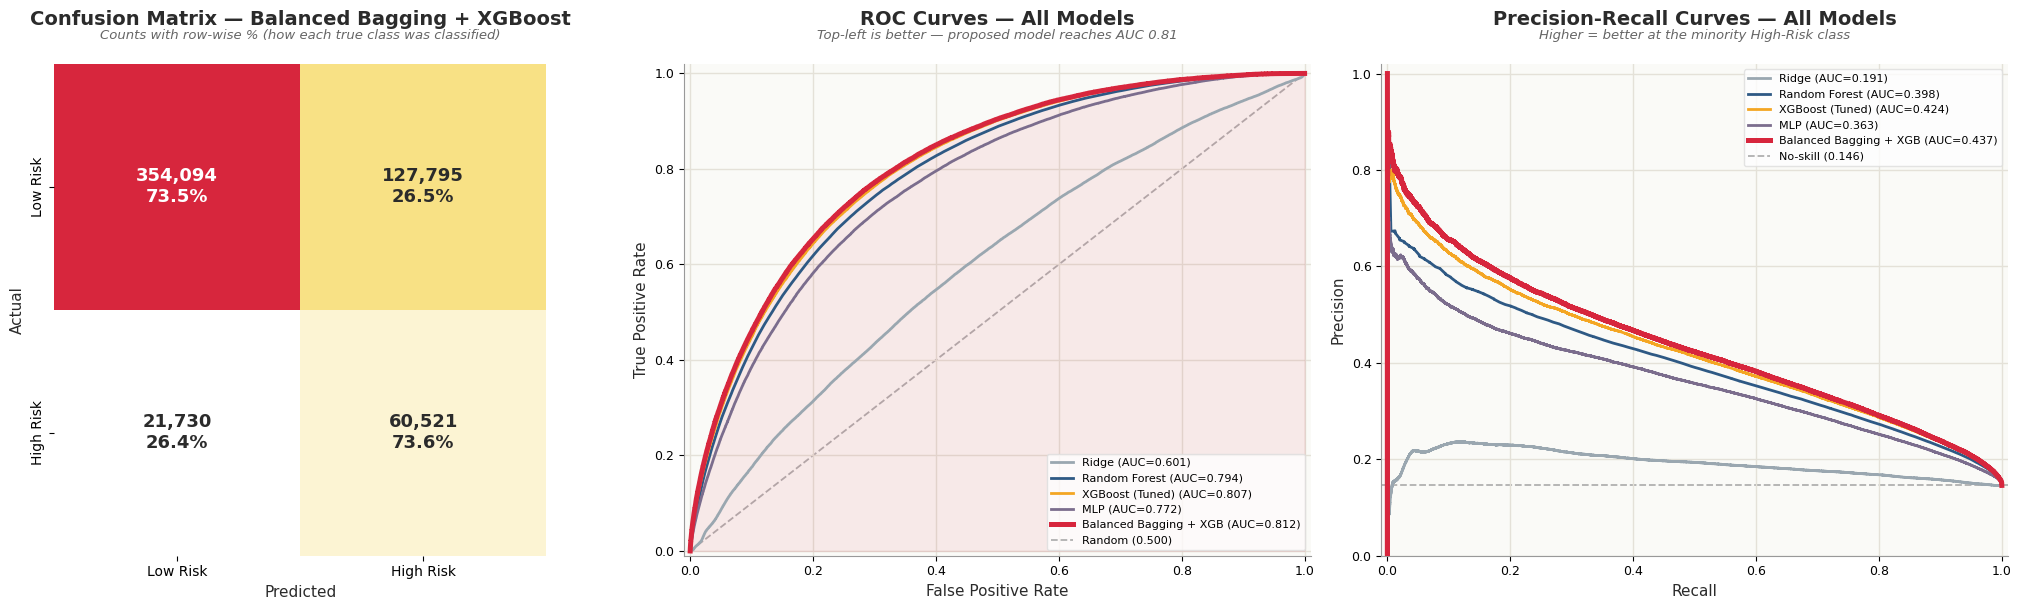

Confusion matrix + ROC + PR curves saved -> outputs/eval/ (side-by-side layout)


In [25]:
def plot_evaluation_curves():
    """Draw the confusion matrix, ROC curve, and precision-recall curve."""
    # ============================================================
    # CELL 21c — EVALUATION PLOTS: CONFUSION MATRIX + ROC + PR CURVES
    # ============================================================
    from sklearn.metrics import roc_curve, precision_recall_curve, auc
    from matplotlib.colors import LinearSegmentedColormap

    plt.close('all')  # close any leftover EDA figures so plt.show() below only displays THIS figure, side by side

    # shared design identity (same palette as the EDA charts)
    WILDFIRE_PALETTE = {'low_risk':'#2E5984','high_risk':'#D7263D','amber':'#F4A623',
                        'ink':'#2B2B2B','grid':'#E4E1D8','panel':'#FAFAF7'}
    EMBER = LinearSegmentedColormap.from_list('ember', ['#FFFFFF','#F4D03F','#D7263D'])  # white -> amber -> ember

    # fixed colour + line weight per model; the proposed model is the red "hero" line
    MODEL_STYLE = {
        'Ridge'                  : ('#9AA7B0', 2.0),   # muted grey  = weakest baseline
        'Random Forest'          : ('#2E5984', 2.0),   # slate blue
        'XGBoost (Tuned)'        : ('#F4A623', 2.0),   # amber
        'MLP'                    : ('#7B6D8D', 2.0),   # dusty purple
        'Balanced Bagging + XGB' : ('#D7263D', 3.6),   # ember red, thick = proposed final model
    }
    models_eval = [
        ('Ridge',                  y_test, ridge_prob),
        ('Random Forest',          y_test, rf_prob),
        ('XGBoost (Tuned)',        y_test, xgb_tuned_prob),
        ('MLP',                    y_test, mlp_prob),
        ('Balanced Bagging + XGB', y_test, bbc_xgb_prob),
    ]

    def _style(ax, title, subtitle, xlabel, ylabel):
        ax.set_facecolor(WILDFIRE_PALETTE['panel'])
        ax.set_title(title, fontsize=14, fontweight='bold', color=WILDFIRE_PALETTE['ink'], pad=28)
        ax.text(0.5, 1.05, subtitle, transform=ax.transAxes, ha='center',
                fontsize=9.5, color='#666666', style='italic')
        ax.set_xlabel(xlabel, fontsize=11, color=WILDFIRE_PALETTE['ink'])
        ax.set_ylabel(ylabel, fontsize=11, color=WILDFIRE_PALETTE['ink'])
        ax.grid(color=WILDFIRE_PALETTE['grid'], linewidth=1, zorder=0)
        ax.spines[['top','right']].set_visible(False)
        ax.spines[['left','bottom']].set_color('#999999')
        ax.tick_params(labelsize=9)

    # ---- single figure, 3 panels side by side: Confusion Matrix | ROC | PR ----
    fig, (ax_cm, ax_roc, ax_pr) = plt.subplots(1, 3, figsize=(21, 6.2))
    fig.patch.set_facecolor('white')

    # ---- 1. Confusion matrix (count + row %, readable on any shade) ----
    cm     = confusion_matrix(y_test, bbc_xgb_pred)
    cm_pct = cm / cm.sum(axis=1, keepdims=True)
    ax_cm.imshow(cm, cmap=EMBER, aspect='equal')
    ax_cm.set_title('Confusion Matrix — Balanced Bagging + XGBoost', fontsize=14,
                 fontweight='bold', color=WILDFIRE_PALETTE['ink'], pad=28)
    ax_cm.text(0.5, 1.05, 'Counts with row-wise % (how each true class was classified)',
            transform=ax_cm.transAxes, ha='center', fontsize=9.5, color='#666666', style='italic')
    ax_cm.set_xticks([0,1]); ax_cm.set_yticks([0,1])
    ax_cm.set_xticklabels(['Low Risk','High Risk'], fontsize=10)
    ax_cm.set_yticklabels(['Low Risk','High Risk'], fontsize=10, rotation=90, va='center')
    ax_cm.set_xlabel('Predicted', fontsize=11, color=WILDFIRE_PALETTE['ink'])
    ax_cm.set_ylabel('Actual',    fontsize=11, color=WILDFIRE_PALETTE['ink'])
    vmax = cm.max()
    for i in range(2):
        for j in range(2):
            txt_color = 'white' if cm[i,j] > vmax*0.5 else WILDFIRE_PALETTE['ink']
            ax_cm.text(j, i, f"{cm[i,j]:,}\n{cm_pct[i,j]*100:.1f}%", ha='center', va='center',
                    color=txt_color, fontsize=13, fontweight='bold')
    ax_cm.spines[:].set_visible(False)

    # ---- 2. ROC curves — all models overlaid ----
    for name, yt, prob in models_eval:
        color, lw = MODEL_STYLE[name]
        fpr, tpr, _ = roc_curve(yt, prob)
        z = 5 if 'Bagging' in name else 3
        ax_roc.plot(fpr, tpr, color=color, linewidth=lw, label=f'{name} (AUC={auc(fpr,tpr):.3f})', zorder=z)
    fpr_h, tpr_h, _ = roc_curve(y_test, bbc_xgb_prob)
    ax_roc.fill_between(fpr_h, tpr_h, alpha=0.08, color=WILDFIRE_PALETTE['high_risk'], zorder=2)  # shade under hero curve
    ax_roc.plot([0,1],[0,1], color='#B0B0B0', linestyle='--', linewidth=1.3, label='Random (0.500)', zorder=1)
    _style(ax_roc, 'ROC Curves — All Models', 'Top-left is better — proposed model reaches AUC 0.81',
           'False Positive Rate', 'True Positive Rate')
    ax_roc.set_xlim(-0.01,1.01); ax_roc.set_ylim(-0.01,1.02)
    ax_roc.legend(loc='lower right', fontsize=8, frameon=True, facecolor='white', edgecolor='#DDDDDD')

    # ---- 3. Precision-Recall curves — all models overlaid ----
    pos_rate = float(y_test.mean())  # no-skill PR baseline = prevalence of High Risk
    for name, yt, prob in models_eval:
        color, lw = MODEL_STYLE[name]
        prec, rec, _ = precision_recall_curve(yt, prob)
        z = 5 if 'Bagging' in name else 3
        ax_pr.plot(rec, prec, color=color, linewidth=lw, label=f'{name} (AUC={auc(rec,prec):.3f})', zorder=z)
    ax_pr.axhline(pos_rate, color='#B0B0B0', linestyle='--', linewidth=1.3,
               label=f'No-skill ({pos_rate:.3f})', zorder=1)
    _style(ax_pr, 'Precision-Recall Curves — All Models',
           'Higher = better at the minority High-Risk class', 'Recall', 'Precision')
    ax_pr.set_xlim(-0.01,1.01); ax_pr.set_ylim(0,1.02)
    ax_pr.legend(loc='upper right', fontsize=8, frameon=True, facecolor='white', edgecolor='#DDDDDD')

    plt.tight_layout()

    # save the combined side-by-side figure
    import os
    os.makedirs('outputs/eval', exist_ok=True)
    plt.savefig('outputs/eval/evaluation_plots_combined.png', dpi=200, facecolor='white', bbox_inches='tight')

    # also save each panel individually, matching the original three separate files
    fig.canvas.draw()
    def _save_panel(ax, path):
        extent = ax.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
        fig.savefig(path, bbox_inches=extent.expanded(1.12, 1.15), dpi=200, facecolor='white')

    _save_panel(ax_cm,  'outputs/eval/confusion_matrix_proposed.png')
    _save_panel(ax_roc, 'outputs/eval/roc_curves_all.png')
    _save_panel(ax_pr,  'outputs/eval/pr_curves_all.png')

    plt.show()
    plt.close(fig)  # done displaying — close it so it can't resurface in a later plt.show()
    print("Confusion matrix + ROC + PR curves saved -> outputs/eval/ (side-by-side layout)")
    globals().update(locals())  # keep results available to later cells

plot_evaluation_curves()


## 22. Train vs Test Accuracy (Overfitting / Underfitting Check)

A diagnostic check confirming whether each model generalises well, overfits, or underfits — an important piece of evidence for the methodology/discussion chapter.

**Key Points**
- **Train ≈ Test accuracy** → the model generalises well.
- **Train >> Test accuracy** → the model is overfitting (memorising training data rather than learning general patterns).
- **Both Train and Test accuracy low** → the model is underfitting (too weak to capture the underlying patterns).
- For the 4 baselines, "train accuracy" is measured on `X_balanced`/`y_balanced` — the exact data each one was fit on. For the proposed model, it's measured on the original `X_train_sc`/`y_train`, since that's what it was actually trained on.
- Produces a grouped bar chart (train vs test, side by side) with a verdict printed per model, and highlights the proposed model's bars for easy visual reference.
- Saved to `outputs/charts/train_vs_test_accuracy.png`.


Train vs Test Accuracy — All 5 Models

TRAIN vs TEST ACCURACY TABLE
                                        Train Accuracy  Test Accuracy  Gap (Train - Test)
Ridge (Baseline)                                0.5731         0.5639              0.0092
Random Forest (Tree-based)                      0.9969         0.7169              0.2800
XGBoost (Boosting)                              0.7967         0.7179              0.0788
MLP (Neural Network)                            0.7096         0.6854              0.0242
Balanced Bagging\n+ XGBoost (Proposed)          0.7513         0.7350              0.0163

Per-model verdict:
   Ridge (Baseline)                 -> Likely UNDERFITTING (both scores low)
   Random Forest (Tree-based)       -> Likely OVERFITTING (train notably higher than test)
   XGBoost (Boosting)               -> Generalises well (train approx. test)
   MLP (Neural Network)             -> Likely UNDERFITTING (both scores low)
   Balanced Bagging                 -> Generalises

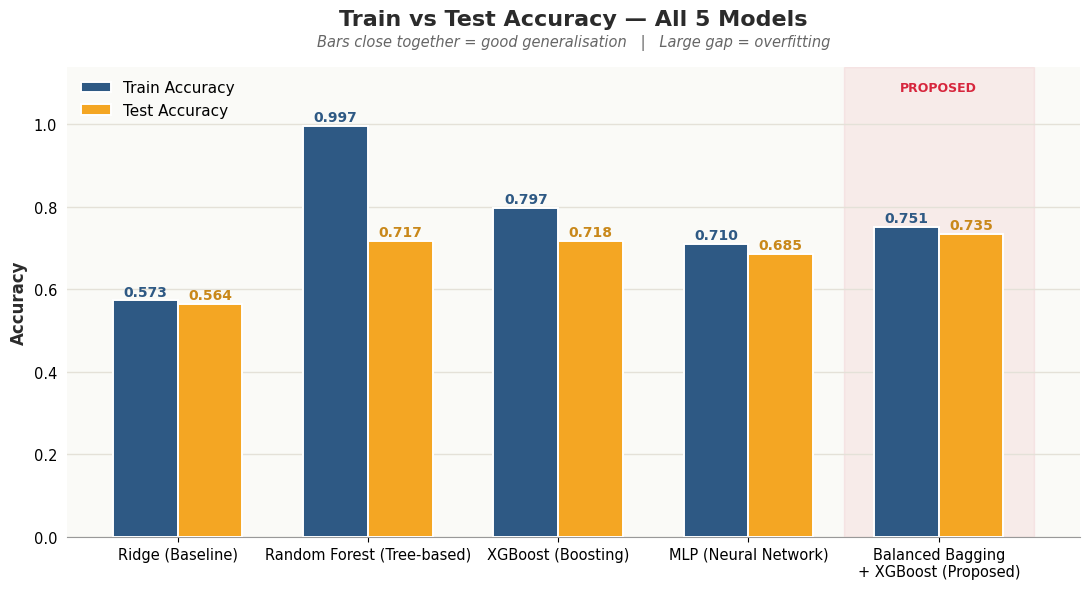


Train vs Test accuracy chart saved -> outputs/charts/train_vs_test_accuracy.png


In [26]:
def check_overfitting():
    """Compare train accuracy vs test accuracy to see if any model overfit."""
    # ============================================================
    # CELL 22 — TRAIN vs TEST ACCURACY (OVERFITTING / UNDERFITTING CHECK)
    # ============================================================
    # Train Accuracy ~= Test Accuracy   -> model generalises well
    # Train Accuracy >> Test Accuracy   -> overfitting (memorised training data)
    # Both Train & Test Accuracy low    -> underfitting (model too weak)
    print("Train vs Test Accuracy — All 5 Models")

    train_test_acc = pd.DataFrame({
        'Ridge (Baseline)': {
            'Train Accuracy': accuracy_score(y_balanced, ridge_train_pred),
            'Test Accuracy' : accuracy_score(y_test, ridge_pred)},
        'Random Forest (Tree-based)': {
            'Train Accuracy': accuracy_score(y_balanced, rf_train_pred),
            'Test Accuracy' : accuracy_score(y_test, rf_pred)},
        'XGBoost (Boosting)': {
            'Train Accuracy': accuracy_score(y_balanced, xgb_tuned_train_pred),
            'Test Accuracy' : accuracy_score(y_test, xgb_tuned_pred)},
        'MLP (Neural Network)': {
            'Train Accuracy': accuracy_score(y_balanced, mlp_train_pred),
            'Test Accuracy' : accuracy_score(y_test, mlp_pred)},
        'Balanced Bagging\n+ XGBoost (Proposed)': {
            'Train Accuracy': accuracy_score(y_train, bbc_xgb_train_pred),
            'Test Accuracy' : accuracy_score(y_test, bbc_xgb_pred)},
    }).T

    train_test_acc['Gap (Train - Test)'] = (
        train_test_acc['Train Accuracy'] - train_test_acc['Test Accuracy']).round(4)
    train_test_acc = train_test_acc.round(4)

    print("\nTRAIN vs TEST ACCURACY TABLE"); print("="*65)
    print(train_test_acc.to_string()); print("="*65)

    print("\nPer-model verdict:")
    for name, row in train_test_acc.iterrows():
        gap = row['Gap (Train - Test)']
        if gap > 0.08:
            verdict = "Likely OVERFITTING (train notably higher than test)"
        elif max(row['Train Accuracy'], row['Test Accuracy']) < 0.75:
            verdict = "Likely UNDERFITTING (both scores low)"
        else:
            verdict = "Generalises well (train approx. test)"
        print(f"   {name.splitlines()[0]:<32} -> {verdict}")

    # -------------------- VISUAL (matched to EDA palette) --------------------
    WILDFIRE_PALETTE = {'low_risk':'#2E5984','high_risk':'#D7263D','amber':'#F4A623',
                        'ink':'#2B2B2B','grid':'#E4E1D8','panel':'#FAFAF7'}

    fig, ax = plt.subplots(figsize=(11,6)); fig.patch.set_facecolor('white')
    ax.set_facecolor(WILDFIRE_PALETTE['panel'])
    x = np.arange(len(train_test_acc)); width = 0.34

    bars_train = ax.bar(x - width/2, train_test_acc['Train Accuracy'], width, label='Train Accuracy',
                        color=WILDFIRE_PALETTE['low_risk'], edgecolor='white', linewidth=1.4, zorder=3)
    bars_test  = ax.bar(x + width/2, train_test_acc['Test Accuracy'], width, label='Test Accuracy',
                        color=WILDFIRE_PALETTE['amber'], edgecolor='white', linewidth=1.4, zorder=3)

    for bars, col in [(bars_train, WILDFIRE_PALETTE['low_risk']), (bars_test, '#C9881A')]:
        for bar in bars:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.012, f"{bar.get_height():.3f}",
                    ha='center', fontsize=10, color=col, fontweight='bold')

    proposed_idx = len(train_test_acc) - 1
    ax.axvspan(proposed_idx-0.5, proposed_idx+0.5, color=WILDFIRE_PALETTE['high_risk'], alpha=0.07, zorder=0)
    ax.text(proposed_idx, 1.08, 'PROPOSED', ha='center', fontsize=9, fontweight='bold',
            color=WILDFIRE_PALETTE['high_risk'])

    ax.set_xticks(x); ax.set_xticklabels(train_test_acc.index, fontsize=10.5)
    ax.set_ylim(0, 1.14)
    ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold', color=WILDFIRE_PALETTE['ink'])
    ax.set_title('Train vs Test Accuracy — All 5 Models', fontsize=16, fontweight='bold',
                 color=WILDFIRE_PALETTE['ink'], pad=30)
    ax.text(0.5, 1.045, 'Bars close together = good generalisation   |   Large gap = overfitting',
            transform=ax.transAxes, ha='center', fontsize=10.5, color='#666666', style='italic')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.1f}'))
    ax.grid(axis='y', color=WILDFIRE_PALETTE['grid'], linewidth=1, zorder=0)
    ax.spines[['top','right','left']].set_visible(False)
    ax.spines['bottom'].set_color('#999999')
    ax.tick_params(left=False, labelsize=10.5)
    ax.legend(loc='upper left', frameon=False, fontsize=11)

    plt.tight_layout()
    plt.savefig('outputs/charts/train_vs_test_accuracy.png', dpi=200, facecolor='white', bbox_inches='tight')
    plt.show()
    print("\nTrain vs Test accuracy chart saved -> outputs/charts/train_vs_test_accuracy.png")
    globals().update(locals())  # keep results available to later cells

check_overfitting()


## 23. ELI5 Explainability (Objective 2: Top Risk Predictors)

Answers **OBJ-2** directly: identifies which environmental features most strongly drive High Risk wildfire predictions, using permutation importance on the tuned XGBoost model.

**Key Points**
- **How it works**: each feature is shuffled (randomised) one at a time, and the drop in ROC-AUC is measured — a bigger drop means the model relied on that feature more heavily.
- Run on a 30,000-row sample of the test set (not the full 1.88M rows) so permutation importance completes in reasonable time, with `n_iter=5` repeats per feature for stability.
- Produces a sorted table (`Feature`, `Importance`, `Std`) and a horizontal bar chart of the top predictors, saved to `outputs/eval/eli5_feature_importance.csv` and `.png`.
- Also displays ELI5's native colour-coded HTML weights table (`eli5.show_weights`) inline in the notebook — this is the explainability artefact most directly tied to the project's second objective.
- This is the final analytical step of the pipeline — by this point, the notebook has both: (1) the best-performing model (OBJ-1, from Cell 21/22), and (2) the strongest environmental predictors driving its predictions (OBJ-2, this cell).


ELI5 Permutation Importance — XGBoost (Tuned)
   Feature  Importance      Std
 LONGITUDE    0.170041 0.003553
  LATITUDE    0.111626 0.004048
 CAUSE_ENC    0.035496 0.000810
 FIRE_YEAR    0.034750 0.001114
 STATE_ENC    0.029636 0.000690
 OWNER_ENC    0.027904 0.001093
     MONTH    0.020706 0.001330
    SEASON    0.002031 0.000156
REGION_ENC    0.001892 0.000312


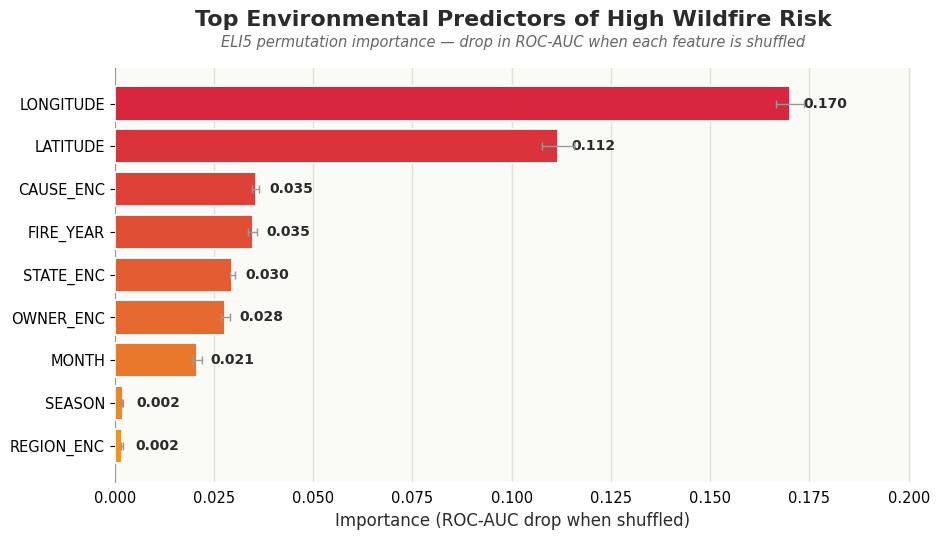


ELI5 importance saved -> outputs/eval/eli5_feature_importance.csv + .png


In [27]:
def explain_feature_importance():
    """Find out which features matter most to the final model's predictions."""
    # ============================================================
    # CELL 23 — ELI5 EXPLAINABILITY (OBJECTIVE 2: Top Risk Predictors)
    # ============================================================
    # Answers OBJ-2: which environmental features most drive HIGH-RISK
    # predictions. ELI5 shuffles each feature and measures how much ROC-AUC
    # drops — a bigger drop means the model relied on that feature more.

    idx = np.random.RandomState(42).choice(len(X_test_sc),
            size=min(30000, len(X_test_sc)), replace=False)
    X_eli, y_eli = X_test_sc[idx], y_test.iloc[idx].values

    perm = PermutationImportance(xgb_tuned, scoring='roc_auc', n_iter=5, random_state=42)
    perm.fit(X_eli, y_eli)

    imp = pd.DataFrame({
        'Feature'   : feature_cols,
        'Importance': perm.feature_importances_,
        'Std'       : perm.feature_importances_std_,
    }).sort_values('Importance', ascending=False).reset_index(drop=True)

    print("ELI5 Permutation Importance — XGBoost (Tuned)"); print("="*50)
    print(imp.to_string(index=False))
    imp.to_csv('outputs/eval/eli5_feature_importance.csv', index=False)

    # ---- Bar chart (matched to EDA palette) ----
    WILDFIRE_PALETTE = {'low_risk':'#2E5984','high_risk':'#D7263D','amber':'#F4A623',
                        'ink':'#2B2B2B','grid':'#E4E1D8','panel':'#FAFAF7'}
    from matplotlib.colors import LinearSegmentedColormap
    EMBER = LinearSegmentedColormap.from_list('ember', ['#F4A623','#D7263D'])  # amber -> ember gradient

    fig, ax = plt.subplots(figsize=(9.5,5.5)); fig.patch.set_facecolor('white')
    ax.set_facecolor(WILDFIRE_PALETTE['panel'])
    ord_imp = imp.sort_values('Importance')                      # ascending so the biggest bar sits at the top
    shades  = EMBER(np.linspace(0.15, 1.0, len(ord_imp)))        # darkest red = most important feature
    bars = ax.barh(ord_imp['Feature'], ord_imp['Importance'], xerr=ord_imp['Std'],
                   color=shades, edgecolor='white', linewidth=1.3, zorder=3,
                   error_kw=dict(ecolor='#999999', capsize=3, lw=1))

    for bar, v in zip(bars, ord_imp['Importance']):              # value label at the end of each bar
        ax.text(bar.get_width()+ord_imp['Importance'].max()*0.02, bar.get_y()+bar.get_height()/2,
                f"{v:.3f}", va='center', fontsize=10, fontweight='bold', color=WILDFIRE_PALETTE['ink'])

    ax.set_title('Top Environmental Predictors of High Wildfire Risk', fontsize=16,
                 fontweight='bold', color=WILDFIRE_PALETTE['ink'], pad=30)
    ax.text(0.5, 1.05, 'ELI5 permutation importance — drop in ROC-AUC when each feature is shuffled',
            transform=ax.transAxes, ha='center', fontsize=10.5, color='#666666', style='italic')
    ax.set_xlabel('Importance (ROC-AUC drop when shuffled)', fontsize=12, color=WILDFIRE_PALETTE['ink'])
    ax.set_xlim(0, ord_imp['Importance'].max()*1.18)
    ax.grid(axis='x', color=WILDFIRE_PALETTE['grid'], linewidth=1, zorder=0)
    ax.spines[['top','right','bottom']].set_visible(False)
    ax.spines['left'].set_color('#999999')
    ax.tick_params(bottom=False, labelsize=10.5)

    plt.tight_layout()
    plt.savefig('outputs/eval/eli5_importance.png', dpi=200, facecolor='white', bbox_inches='tight')
    plt.show()
    print("\nELI5 importance saved -> outputs/eval/eli5_feature_importance.csv + .png")

    # eli5's native weights table (renders as a coloured HTML table in Colab)
    eli5.show_weights(perm, feature_names=feature_cols, top=len(feature_cols))
    globals().update(locals())  # keep results available to later cells

explain_feature_importance()
